# E5: DeMemteAttractor

Notebook separado para conservar la variante final `E5 combined dropout + OOD tau 1.50`. Incluye solo lo necesario para cargar el checkpoint final, revisar metricas guardadas, graficar el comportamiento del gate, recomputar evaluacion completa si hace falta y reentrenar E5 de forma opcional.

In [1]:
import os
import copy
import glob
import json
import math
import random
import csv
import platform
from dataclasses import dataclass, asdict
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
try:
    import pandas as pd
except ImportError as exc:
    pd = None
    print('pandas unavailable; falling back to plain records:', exc)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())


torch: 2.12.0+cu130
torchvision: 0.27.0+cu130
cuda: True


In [2]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 16
    num_workers: int = 2

    val_ratio: float = 0.2
    split_seed: int = 42

    lr_vq: float = 3e-4
    lr_cls: float = 1e-4
    lr_attractor: float = 3e-4
    lr_gate: float = 1e-3
    lr_resnet_transfer_backbone: float = 1e-5
    lr_resnet_transfer_head: float = 1e-4
    weight_decay: float = 1e-4

    epochs_baseline_max: int = 30
    epochs_phase1_max: int = 4
    epochs_phase2_max: int = 6
    epochs_phase3_max: int = 10

    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4
    scheduler_factor: float = 0.5
    scheduler_patience: int = 2

    latent_dim: int = 128
    attractor_hidden: int = 512
    gate_hidden: int = 16
    num_embeddings: int = 1024
    commitment_cost: float = 0.25
    vq_temperature: float = 1.0

    familiarity_midpoint: float = 0.0
    familiarity_width: float = 1.0
    ood_tau: float = 2.0
    ood_beta: float = 4.0

    denoise_weight: float = 0.5
    vq_weight: float = 0.25
    antipareidolia_weight: float = 0.1
    gate_entropy_reg: float = 0.01
    gate_raw_entropy_reg: float = 0.0
    weak_sigreg_weight: float = 0.01
    weak_sigreg_sketch_dim: int = 64
    gate_init_prob: float = 0.1
    gate_prior_floor: float = 0.02
    gate_dropout: float = 0.0

    masked_feature_ratio: float = 0.35
    train_corrupt_prob: float = 0.7

    phase3_memory_grad_mode: str = 'full'  # full | freeze_vq | vq_clean_only
    phase3_lock_familiarity: bool = False
    phase3_backbone_train_mode: str = 'frozen'  # frozen | partial_unfreeze
    resnet_transfer_train_mode: str = 'full_finetune'  # full_finetune | layer4
    gate_order_loss_weight: float = 0.0
    gate_order_loss_margin: float = 0.03
    gate_order_gauss_severity: float = 1.5
    gate_order_blur_severity: float = 0.6
    gate_order_cutout_severity: float = 0.35

    pareto_clean_floor: float = 0.748252
    pareto_corrupt_floor: float = 0.399889
    gate_order_success_margin: float = 0.03
    acceptance_harmful_max: float = 0.006099
    acceptance_pareidolia_max: float = 0.005922
    acceptance_gate_raw_max: float = 0.95

    max_train_batches_debug: int = 10000000
    max_val_batches_debug: int = 10000000
    eval_max_batches: int = 10000000

    artifacts_root: str = './out/artifacts'
    experiment_name: str = 'dememte_e5_final'
    retrain_comparison_if_missing: bool = False
    run_e0_latest_checkpoint_diagnostic: bool = False
    experiment_names: tuple = ('e5_combined_dropout_ood_tau_150',)

    # Bouthillier et al. recomiendan contabilizar varianza por seed/sampling;
    # por eso el pipeline final ejecuta multi-seed por defecto, no una corrida unica.
    critical_protocol_enabled: bool = True
    critical_seeds: tuple = (42, 43, 44, 45, 46)
    # Nilsback-Zisserman/Flowers102 define splits oficiales; mantenemos el split
    # historico como benchmark principal por continuidad y ejecutamos el oficial
    # como auditoria secundaria de comparabilidad.
    benchmark_protocol: str = 'historical_trainval_resplit'
    run_official_split_secondary_eval: bool = True
    critical_artifacts_dir: str = './out/artifacts/dememte_e5_critical'
    run_critical_bootstrap: bool = True
    run_critical_mcnemar: bool = True
    # Lee et al. justifican Mahalanobis en features como baseline OOD;
    # se calcula dentro de la evaluacion final, no como notebook aparte.
    run_critical_mahalanobis: bool = True
    run_critical_risk_coverage: bool = True
    run_critical_ood_scores: bool = True
    run_critical_ablations: bool = True
    run_resnet_transfer_baseline: bool = True
    bootstrap_iters: int = 1000
    save_prediction_logits: bool = False

    device: str = 'cuda'


def resolve_existing_path(candidates):
    for candidate in candidates:
        p = Path(candidate).expanduser()
        if p.exists():
            return str(p)
    return str(Path(candidates[0]))

cfg = Config()
cfg.data_dir = resolve_existing_path(['../data', 'experiments/data', './data'])
if not torch.cuda.is_available():
    raise RuntimeError('CUDA no esta disponible. Este notebook esta configurado para ejecutar en GPU (device=cuda).')
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()
print(json.dumps(asdict(cfg), indent=2))


{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "val_ratio": 0.2,
  "split_seed": 42,
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "lr_attractor": 0.0003,
  "lr_gate": 0.001,
  "lr_resnet_transfer_backbone": 1e-05,
  "lr_resnet_transfer_head": 0.0001,
  "weight_decay": 0.0001,
  "epochs_baseline_max": 30,
  "epochs_phase1_max": 4,
  "epochs_phase2_max": 6,
  "epochs_phase3_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 128,
  "attractor_hidden": 512,
  "gate_hidden": 16,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "familiarity_midpoint": 0.0,
  "familiarity_width": 1.0,
  "ood_tau": 2.0,
  "ood_beta": 4.0,
  "denoise_weight": 0.5,
  "vq_weight": 0.25,
  "antipareidolia_weight": 0.1,
  "gate_entropy_reg": 0.01,
  "gate_raw_entropy_reg": 0.0,
  "weak_sigreg_weight": 0.01,
  "weak_sigreg_sketch_dim": 64,
  "gate_init_prob

In [3]:

def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)
    ys = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        ys.append(int(y))
    return np.array(ys)

def _make_flower_transforms():
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return transform_train, transform_eval

def seed_everything(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

def build_datasets(config: Config, download: bool = False, protocol: str = None, seed_override: int = None):
    protocol = protocol or config.benchmark_protocol
    split_seed = config.split_seed if seed_override is None else int(seed_override)
    transform_train, transform_eval = _make_flower_transforms()

    tr = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=download, transform=transform_train)
    va_train = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=download, transform=transform_train)
    va_eval = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=download, transform=transform_eval)
    te = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=download, transform=transform_eval)

    # Protocolo principal heredado del experimento E5: maximiza datos de train en
    # Flowers102 pequeno, pero conserva el test oficial intacto. Esta decision queda
    # trazada porque Datasheets for Datasets exige documentar particiones y usos.
    if protocol == 'historical_trainval_resplit':
        cv_ds = ConcatDataset([tr, va_train])
        cv_y = np.concatenate([_extract_labels(tr), _extract_labels(va_train)], axis=0)
        splitter = StratifiedShuffleSplit(n_splits=1, test_size=config.val_ratio, random_state=split_seed)
        train_idx, val_idx = next(splitter.split(np.zeros(len(cv_y)), cv_y))
        tr_ds = Subset(cv_ds, train_idx.tolist())
        va_ds = Subset(cv_ds, val_idx.tolist())
        protocol_meta = {
            'protocol': protocol,
            'split_seed': split_seed,
            'train_size': len(tr_ds),
            'val_size': len(va_ds),
            'test_size': len(te),
            'note': 'Principal historico: train+val concatenados y redivididos; test oficial intacto.',
        }
    # Protocolo secundario comparable: usa train/val/test oficiales de Flowers102
    # para evitar que la conclusion dependa solo de la redivision historica.
    elif protocol == 'official':
        tr_ds = tr
        va_ds = va_eval
        protocol_meta = {
            'protocol': protocol,
            'split_seed': None,
            'train_size': len(tr_ds),
            'val_size': len(va_ds),
            'test_size': len(te),
            'note': 'Secundario comparable: train oficial, val oficial y test oficial.',
        }
    else:
        raise ValueError(f'Unknown dataset protocol: {protocol}')

    generator = torch.Generator()
    generator.manual_seed(split_seed)
    tr_loader = DataLoader(
        tr_ds,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=True,
        generator=generator,
    )
    va_loader = DataLoader(va_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    te_loader = DataLoader(te, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return tr_loader, va_loader, te_loader, protocol_meta

trainloader, valloader, testloader, DATASET_PROTOCOL_META = build_datasets(cfg)
print('protocol:', DATASET_PROTOCOL_META)
print('train batches:', len(trainloader), '| val batches:', len(valloader), '| test batches:', len(testloader))


protocol: {'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149, 'note': 'Principal historico: train+val concatenados y redivididos; test oficial intacto.'}
train batches: 102 | val batches: 26 | test batches: 385


In [4]:
def make_backbone():
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(base.children())[:-2])

def apply_train_corruption(x):
    if random.random() > cfg.train_corrupt_prob:
        return x

    mode = random.choice(['gaussian_noise', 'pixel_mask', 'cutout', 'blur'])

    if mode == 'gaussian_noise':
        level = random.uniform(0.4, 1.3)
        return x + level * torch.randn_like(x)

    if mode == 'pixel_mask':
        level = random.uniform(0.20, 0.65)
        keep = (torch.rand(x.size(0), 1, x.size(2), x.size(3), device=x.device) > level).float()
        return x * keep

    if mode == 'cutout':
        level = random.uniform(0.20, 0.45)
        b, _, h, w = x.shape
        cut_h = max(1, int(h * level))
        cut_w = max(1, int(w * level))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        for i in range(b):
            t = random.randint(0, max(0, h - cut_h))
            l = random.randint(0, max(0, w - cut_w))
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask

    level = random.uniform(0.30, 0.80)
    channels = x.size(1)
    kernel_size = 7
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    blur = F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)
    return (1.0 - level) * x + level * blur

In [5]:
class VectorQuantizer2D(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25, temperature=1.0):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.temperature = temperature
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e):
        b, c, h, w = z_e.shape
        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z_e_perm.view(-1, c)
        emb = self.embedding.weight
        distances = flat.pow(2).sum(1, keepdim=True) - 2 * flat @ emb.t() + emb.pow(2).sum(1, keepdim=True).t()
        idx = torch.argmin(distances, dim=1)
        one_hot = F.one_hot(idx, self.num_embeddings).type(flat.dtype)
        q_flat = one_hot @ emb
        q = q_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        vq_loss = self.commitment_cost * F.mse_loss(z_e, q.detach()) + F.mse_loss(q, z_e.detach())
        q_st = z_e + (q - z_e).detach()
        dq_map = ((z_e - q.detach()) ** 2).mean(dim=1, keepdim=True)
        temp = max(1e-6, float(self.temperature))
        soft_assign = F.softmax(-distances / temp, dim=1).view(b, h, w, self.num_embeddings)
        return q_st, vq_loss, dq_map, soft_assign

In [6]:
class LatentProjector(nn.Module):
    def __init__(self, in_channels=512, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, latent_dim, kernel_size=1),
            nn.BatchNorm2d(latent_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class LatentUnprojector(nn.Module):
    def __init__(self, latent_dim=128, out_channels=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)

In [7]:
class AttractorMemory(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z):
        b, c, h, w = z.shape
        toks = z.flatten(2).transpose(1, 2).contiguous().view(b * h * w, c)
        completed = toks + self.net(toks)
        return completed.view(b, h * w, c).transpose(1, 2).view(b, c, h, w).contiguous()

In [8]:
class AmbiguityGate(nn.Module):
    def __init__(
        self,
        num_classes=102,
        num_embeddings=1024,
        hidden=16,
        familiarity_midpoint=0.0,
        familiarity_width=1.0,
        ood_tau=2.0,
        ood_beta=4.0,
        gate_init_prob=0.1,
        gate_prior_floor=0.02,
        gate_dropout=0.0,
        use_uncertainty=True,
        use_familiarity=True,
        use_conflict=True,
        use_ood=True,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_embeddings = num_embeddings
        self.ood_tau = ood_tau
        self.ood_beta = ood_beta
        self.gate_prior_floor = gate_prior_floor
        self.gate_dropout = gate_dropout
        self.use_uncertainty = use_uncertainty
        self.use_familiarity = use_familiarity
        self.use_conflict = use_conflict
        self.use_ood = use_ood

        self.midpoint = nn.Parameter(torch.tensor(float(familiarity_midpoint)))
        self.log_width = nn.Parameter(torch.log(torch.tensor(float(familiarity_width))))
        self.gate_dropout_layer = nn.Dropout(float(gate_dropout)) if gate_dropout > 0 else nn.Identity()
        self.mlp = nn.Sequential(nn.Linear(4, hidden), nn.GELU(), nn.Linear(hidden, 1))
        init_prob = min(max(float(gate_init_prob), 1e-4), 1.0 - 1e-4)
        nn.init.constant_(self.mlp[-1].bias, math.log(init_prob / (1.0 - init_prob)))

        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def _update_ema(self, dq_score):
        with torch.no_grad():
            batch_mean = dq_score.mean()
            batch_var = dq_score.var(unbiased=False) if dq_score.numel() > 1 else torch.tensor(0.0, device=dq_score.device)
            momentum = 0.99
            if self.dq_ema_counted.item() == 0:
                self.dq_ema_mean.fill_(batch_mean)
                self.dq_ema_var.fill_(batch_var)
            else:
                self.dq_ema_mean.mul_(momentum).add_(batch_mean * (1 - momentum))
                self.dq_ema_var.mul_(momentum).add_(batch_var * (1 - momentum))
            self.dq_ema_counted.add_(1.0)

    def forward(self, aux_logits, dq_map, soft_assign, update_ema=True):
        b = aux_logits.size(0)
        dq_score = dq_map.flatten(1).mean(dim=1, keepdim=True)
        if self.training and update_ema:
            self._update_ema(dq_score)

        dq_std = torch.sqrt(self.dq_ema_var.clamp_min(0.0)) + 1e-5
        dq_norm = (dq_score - self.dq_ema_mean) / dq_std

        probs = F.softmax(aux_logits, dim=1)
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(dim=1, keepdim=True) / math.log(self.num_classes)

        width = torch.exp(self.log_width).clamp_min(1e-4)
        familiarity = torch.exp(-((dq_norm - self.midpoint) ** 2) / (2 * width ** 2))

        conflict = -(soft_assign * torch.log(soft_assign + 1e-8)).sum(dim=-1).mean(dim=(1, 2), keepdim=False).view(b, 1) / math.log(self.num_embeddings)
        ood_risk = torch.sigmoid(self.ood_beta * (dq_norm - self.ood_tau))

        zero = torch.zeros_like(uncertainty)
        gate_inputs = torch.cat([
            uncertainty if self.use_uncertainty else zero,
            familiarity if self.use_familiarity else zero,
            conflict if self.use_conflict else zero,
            (1.0 - ood_risk) if self.use_ood else zero,
        ], dim=1)
        one = torch.ones_like(uncertainty)
        uncertainty_factor = uncertainty if self.use_uncertainty else one
        familiarity_factor = familiarity if self.use_familiarity else one
        ood_factor = (1.0 - ood_risk) if self.use_ood else one
        gate_prior = (uncertainty_factor * familiarity_factor * ood_factor).clamp(0.0, 1.0)
        gate_hidden = self.mlp[1](self.mlp[0](gate_inputs))
        gate_hidden = self.gate_dropout_layer(gate_hidden)
        gate_raw = torch.sigmoid(self.mlp[2](gate_hidden))
        floor = min(max(float(self.gate_prior_floor), 0.0), 1.0)
        gate_score = floor + (1.0 - floor) * gate_prior * gate_raw
        gate = gate_score.view(b, 1, 1, 1)
        signals = {
            'dq_norm': dq_norm.view(b, 1, 1, 1),
            'uncertainty': uncertainty.view(b, 1, 1, 1),
            'familiarity': familiarity.view(b, 1, 1, 1),
            'conflict': conflict.view(b, 1, 1, 1),
            'ood_risk': ood_risk.view(b, 1, 1, 1),
            'gate_prior': gate_prior.view(b, 1, 1, 1),
            'gate_raw': gate_raw.view(b, 1, 1, 1),
            'gate_inputs': gate_inputs,
        }
        return gate, signals

In [9]:
# SIGReg entra como regularizacion latente: la critica lo trata como hipotesis
# metodologica emergente, asi que se conserva pero queda ablado por seed/variante.
def sigreg_weak_loss(x, sketch_dim=64):
    if x.dim() != 2:
        x = x.view(-1, x.size(-1))
    n, c = x.size()
    if n <= 1:
        return x.new_zeros(())
    if c > sketch_dim:
        sketch = torch.randn(sketch_dim, c, device=x.device, dtype=x.dtype) / (c ** 0.5)
        x = x @ sketch.t()
        c = sketch_dim
    x = x - x.mean(dim=0, keepdim=True)
    cov = (x.t() @ x) / (n - 1 + 1e-6)
    target = torch.eye(c, device=x.device, dtype=x.dtype)
    return torch.norm(cov - target, p='fro')

def sigreg_latent_loss(z, sketch_dim=64):
    tokens = z.flatten(2).transpose(1, 2).reshape(-1, z.size(1))
    return sigreg_weak_loss(tokens, sketch_dim=sketch_dim)

def set_requires_grad(module, requires_grad):
    for p in module.parameters():
        p.requires_grad = requires_grad

def gate_entropy_regularizer(gate):
    g = gate.clamp(1e-6, 1.0 - 1e-6)
    entropy = -(g * torch.log(g) + (1.0 - g) * torch.log(1.0 - g))
    return -entropy.mean()

# Control funcional de dano: penaliza abrir memoria cuando la familiaridad baja
# o cuando la intervencion convierte un acierto base en error; se abla con
# no_antipareidolia para que no sea solo una declaracion de seguridad.
def antipareidolia_loss(debug_dirty, logits_dirty, y):
    gate = debug_dirty['gate']
    familiarity = debug_dirty['familiarity']
    anti_ood = (gate * (1.0 - familiarity).detach()).mean()
    base_pred = debug_dirty['logits_base'].detach().argmax(1)
    final_pred = logits_dirty.detach().argmax(1)
    harmful = ((base_pred == y) & (final_pred != y)).float().view(-1, 1, 1, 1)
    harmful_gate = (gate * harmful).mean()
    return anti_ood + harmful_gate

def configure_phase1(model):
    model.set_backbone_trainable(False)
    model.backbone.eval()
    set_requires_grad(model.projector, True)
    set_requires_grad(model.vq, True)
    set_requires_grad(model.unprojector, True)
    set_requires_grad(model.attractor, False)
    set_requires_grad(model.gate, False)
    set_requires_grad(model.aux_classifier, False)
    set_requires_grad(model.classifier, False)

def configure_phase2(model):
    model.set_backbone_trainable(False)
    model.backbone.eval()
    set_requires_grad(model.projector, False)
    set_requires_grad(model.vq, False)
    set_requires_grad(model.unprojector, False)
    model.projector.eval()
    model.vq.eval()
    model.unprojector.eval()
    set_requires_grad(model.attractor, True)
    set_requires_grad(model.gate, True)
    set_requires_grad(model.aux_classifier, True)
    set_requires_grad(model.classifier, True)

def configure_phase3(model, config=cfg, train_backbone=False):
    model.set_backbone_trainable(False)
    model.backbone.eval()
    if getattr(config, 'phase3_backbone_train_mode', 'frozen') == 'partial_unfreeze':
        # Kornblith et al. y SpotTune muestran que fixed features pueden subestimar
        # transfer en datasets pequenos/fine-grained; por eso layer4 se abla como
        # descongelado parcial en el entrenamiento original de fase 3.
        # ResNet18 is stored as Sequential(children[:-2]); index 7 is layer4.
        if train_backbone:
            model.backbone[-1].train()
        for p in model.backbone[-1].parameters():
            p.requires_grad = True
    memory_trainable = config.phase3_memory_grad_mode != 'freeze_vq'
    set_requires_grad(model.projector, memory_trainable)
    set_requires_grad(model.vq, memory_trainable)
    set_requires_grad(model.unprojector, memory_trainable)
    if not memory_trainable:
        model.projector.eval()
        model.vq.eval()
        model.unprojector.eval()
    set_requires_grad(model.attractor, True)
    set_requires_grad(model.gate, True)
    if config.phase3_lock_familiarity:
        model.gate.midpoint.requires_grad = False
        model.gate.log_width.requires_grad = False
    set_requires_grad(model.aux_classifier, True)
    set_requires_grad(model.classifier, True)

def make_optimizer_phase1(model, config):
    params = list(model.projector.parameters()) + list(model.vq.parameters()) + list(model.unprojector.parameters())
    return optim.AdamW(params, lr=config.lr_vq, weight_decay=config.weight_decay)

def make_optimizer_phase2(model, config):
    return optim.AdamW([
        {'params': model.attractor.parameters(), 'lr': config.lr_attractor},
        {'params': model.gate.parameters(), 'lr': config.lr_gate},
        {'params': model.aux_classifier.parameters(), 'lr': config.lr_cls},
        {'params': model.classifier.parameters(), 'lr': config.lr_cls},
    ], weight_decay=config.weight_decay)

def _trainable_params(module):
    return [p for p in module.parameters() if p.requires_grad]

def make_optimizer_phase3(model, config):
    param_groups = []
    memory_params = _trainable_params(model.projector) + _trainable_params(model.vq) + _trainable_params(model.unprojector)
    if memory_params:
        param_groups.append({'params': memory_params, 'lr': config.lr_vq})
    param_groups.append({'params': _trainable_params(model.attractor), 'lr': config.lr_attractor})
    param_groups.append({'params': _trainable_params(model.gate), 'lr': config.lr_gate})
    param_groups.append({'params': _trainable_params(model.aux_classifier) + _trainable_params(model.classifier), 'lr': config.lr_cls})
    backbone_params = _trainable_params(model.backbone)
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': min(config.lr_cls, 1e-5)})
    return optim.AdamW(param_groups, weight_decay=config.weight_decay)

def run_epoch_phase1(model, loader, optimizer, train):
    model.train(train)
    configure_phase1(model)
    totals = {'loss': 0.0, 'recon': 0.0, 'vq': 0.0, 'sigreg': 0.0, 'n': 0}
    for bi, (x, _) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        recon_loss, vq_loss, sigreg_loss = model.pretrain_latent(x, feature_mask_ratio=cfg.masked_feature_ratio, sigreg_sketch_dim=cfg.weak_sigreg_sketch_dim)
        loss = 0.5 * recon_loss + 0.25 * vq_loss + cfg.weak_sigreg_weight * sigreg_loss
        if train:
            loss.backward()
            optimizer.step()
        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['recon'] += recon_loss.item() * bs
        totals['vq'] += vq_loss.item() * bs
        totals['sigreg'] += sigreg_loss.item() * bs
        totals['n'] += bs
    for k in ['loss', 'recon', 'vq', 'sigreg']:
        totals[k] /= max(1, totals['n'])
    return totals


In [10]:
class DeMemteAttractor(nn.Module):
    def __init__(
        self,
        backbone,
        num_classes,
        latent_dim=128,
        num_embeddings=1024,
        attractor_hidden=512,
        gate_hidden=16,
        commitment_cost=0.25,
        vq_temperature=1.0,
        familiarity_midpoint=0.0,
        familiarity_width=1.0,
        ood_tau=2.0,
        ood_beta=4.0,
        gate_init_prob=0.1,
        gate_prior_floor=0.02,
        gate_dropout=0.0,
        use_uncertainty=True,
        use_familiarity=True,
        use_conflict=True,
        use_ood=True,
        # Ablacion arquitectonica: permite medir si el atractor residual aporta
        # pattern completion real o si el clasificador/base explica la ganancia.
        disable_attractor=False,
    ):
        super().__init__()
        self.backbone = backbone
        self.projector = LatentProjector(512, latent_dim)
        self.vq = VectorQuantizer2D(num_embeddings, latent_dim, commitment_cost, vq_temperature)
        self.attractor = AttractorMemory(latent_dim, attractor_hidden)
        self.gate = AmbiguityGate(
            num_classes=num_classes,
            num_embeddings=num_embeddings,
            hidden=gate_hidden,
            familiarity_midpoint=familiarity_midpoint,
            familiarity_width=familiarity_width,
            ood_tau=ood_tau,
            ood_beta=ood_beta,
            gate_init_prob=gate_init_prob,
            gate_prior_floor=gate_prior_floor,
            gate_dropout=gate_dropout,
            use_uncertainty=use_uncertainty,
            use_familiarity=use_familiarity,
            use_conflict=use_conflict,
            use_ood=use_ood,
        )
        self.unprojector = LatentUnprojector(latent_dim, 512)
        self.aux_classifier = nn.Linear(512, num_classes)
        self.classifier = nn.Linear(512, num_classes)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.disable_attractor = bool(disable_attractor)

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def _mask_features(self, feats, mask_ratio):
        if mask_ratio <= 0:
            return feats
        b, _, h, w = feats.shape
        keep = (torch.rand(b, 1, h, w, device=feats.device) > mask_ratio).float()
        return feats * keep

    def encode_z(self, x):
        feats = self.backbone(x)
        z = self.projector(feats)
        return feats, z

    def pretrain_latent(self, x, feature_mask_ratio=0.0, update_ema=True, sigreg_sketch_dim=64):
        feats = self.backbone(x)
        vq_input = self._mask_features(feats, feature_mask_ratio if self.training else 0.0)
        z = self.projector(vq_input)
        zq, vq_loss, dq_map, soft_assign = self.vq(z)
        rec_feats = self.unprojector(zq)
        if self.training and update_ema:
            aux_logits = self.aux_classifier(self.pool(feats).flatten(1))
            self.gate(aux_logits, dq_map, soft_assign, update_ema=True)
        recon_loss = F.mse_loss(rec_feats, feats.detach())
        sigreg_loss = sigreg_latent_loss(z, sigreg_sketch_dim)
        return recon_loss, vq_loss, sigreg_loss

    def forward(self, x, target_z=None, update_ema=True, return_debug=False, feature_mask_ratio=0.0):
        feats = self.backbone(x)
        vq_feats = self._mask_features(feats, feature_mask_ratio if self.training else 0.0)
        z = self.projector(vq_feats)
        zq, vq_loss, dq_map, soft_assign = self.vq(z)
        # Hopfield/denoising autoencoders sustentan la intuicion de memoria
        # asociativa; esta linea hace que la ablation attractor_disabled elimine
        # exactamente esa correccion, sin tocar el resto del pipeline.
        z_completed = z if self.disable_attractor else self.attractor(z)
        delta = z_completed - z.detach()

        feats_flat = self.pool(feats).flatten(1)
        aux_logits = self.aux_classifier(feats_flat)
        gate, signals = self.gate(aux_logits, dq_map, soft_assign, update_ema=update_ema)

        z_final = z + gate * delta
        feats_final = self.unprojector(z_final)
        logits = self.classifier(self.pool(feats_final).flatten(1))
        target = z.detach() if target_z is None else target_z.detach()
        denoise_loss = F.mse_loss(z_completed, target)

        if return_debug:
            debug = {
                'gate': gate,
                'delta': delta,
                'z': z,
                'z_completed': z_completed,
                'dq_map': dq_map,
                'logits_base': aux_logits,
                'clean_feats': feats,
                'enhanced_feats': feats_final,
                **signals,
            }
            return logits, denoise_loss, vq_loss, debug
        return logits, denoise_loss, vq_loss



class ResNetTransferBaseline(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)
        self.num_classes = num_classes

    def forward(self, x, update_ema=True, return_debug=False, **kwargs):
        feats = self.backbone(x)
        pooled = self.pool(feats).flatten(1)
        logits = self.classifier(pooled)
        if not return_debug:
            return logits

        probs = F.softmax(logits, dim=1)
        uncertainty = -(probs * torch.log(probs + 1e-8)).sum(dim=1, keepdim=True) / math.log(self.num_classes)
        zeros = torch.zeros(x.size(0), 1, 1, 1, device=x.device, dtype=logits.dtype)
        debug = {
            'gate': zeros,
            'delta': torch.zeros_like(feats),
            'dq_norm': zeros,
            'uncertainty': uncertainty.view(x.size(0), 1, 1, 1),
            'familiarity': zeros,
            'conflict': zeros,
            'ood_risk': zeros,
            'gate_prior': zeros,
            'gate_raw': zeros,
            'logits_base': logits,
            'clean_feats': feats,
            'enhanced_feats': feats,
        }
        return logits, logits.new_zeros(()), logits.new_zeros(()), debug



FINAL_VARIANT = 'e5_combined_dropout_ood_tau_150'
FINAL_LABEL = 'E5 combined dropout + OOD tau 1.50'
RESNET_TRANSFER_VARIANT = 'resnet18_transfer_baseline'
RESNET_TRANSFER_LABEL = 'ResNet18 transfer baseline'


def experiment_specs():
    base_flags = dict(use_uncertainty=True, use_familiarity=True, use_conflict=True, use_ood=True, disable_attractor=False)
    e5_overrides = {
        'ood_tau': 1.5,
        'ood_beta': 8.0,
        'familiarity_width': 0.5,
        'phase3_lock_familiarity': True,
        'gate_dropout': 0.1,
        'lr_gate': 1e-4,
        'gate_raw_entropy_reg': 0.01,
    }
    # Las variantes criticas son parte del pipeline, no un analisis externo:
    # cada una responde una amenaza metodologica del diseno E5.
    return {
        FINAL_VARIANT: {
            'label': FINAL_LABEL,
            'base_variant': FINAL_VARIANT,
            'flags': base_flags,
            'overrides': e5_overrides,
        },
        # Lee et al. y trabajos de OOD advierten que una senal OOD debe compararse
        # contra su ausencia y contra baselines de distancia.
        'no_ood': {
            'label': 'Ablation no OOD',
            'base_variant': 'no_ood',
            'flags': dict(base_flags, use_ood=False),
            'overrides': e5_overrides,
        },
        # Zhou et al. cuestiona reconstruccion/familiaridad ingenua como OOD;
        # esta ablation prueba si familiaridad ayuda o solo introduce sesgo.
        'no_familiarity': {
            'label': 'Ablation no familiarity',
            'base_variant': 'no_familiarity',
            'flags': dict(base_flags, use_familiarity=False),
            'overrides': e5_overrides,
        },
        'no_antipareidolia': {
            'label': 'Ablation no anti-pareidolia',
            'base_variant': 'no_antipareidolia',
            'flags': base_flags,
            'overrides': e5_overrides,
            'antipareidolia_weight': 0.0,
        },
        'freeze_vq_phase3': {
            'label': 'Ablation freeze VQ Phase 3',
            'base_variant': 'freeze_vq_phase3',
            'flags': base_flags,
            'overrides': dict(e5_overrides, phase3_memory_grad_mode='freeze_vq'),
        },
        # Transfer learning: comparar backbone congelado contra descongelado parcial
        # evita sobrerreclamar que ResNet18 fixed features es el techo adecuado.
        'partial_unfreeze_backbone': {
            'label': 'Ablation partial backbone unfreeze',
            'base_variant': 'partial_unfreeze_backbone',
            'flags': base_flags,
            'overrides': dict(e5_overrides, phase3_backbone_train_mode='partial_unfreeze'),
        },
        'attractor_disabled': {
            'label': 'Ablation attractor disabled',
            'base_variant': 'attractor_disabled',
            'flags': dict(base_flags, disable_attractor=True),
            'overrides': e5_overrides,
        },
    }


def critical_variant_names(config=cfg):
    names = [FINAL_VARIANT]
    if config.run_critical_ablations:
        names.extend([
            'no_ood',
            'no_familiarity',
            'no_antipareidolia',
            'freeze_vq_phase3',
            'partial_unfreeze_backbone',
            'attractor_disabled',
        ])
    if getattr(config, 'run_resnet_transfer_baseline', True):
        names.append(RESNET_TRANSFER_VARIANT)
    return tuple(names)


def config_for_experiment(base_config: Config, experiment_name: str):
    specs = experiment_specs()
    if experiment_name not in specs:
        raise KeyError(f'Unknown experiment: {experiment_name}')
    config = copy.deepcopy(base_config)
    for key, value in specs[experiment_name].get('overrides', {}).items():
        setattr(config, key, value)
    return config


def reset_gate_calibration_from_config(model, config: Config):
    with torch.no_grad():
        model.gate.midpoint.fill_(float(config.familiarity_midpoint))
        model.gate.log_width.fill_(math.log(float(config.familiarity_width)))
    model.gate.ood_tau = float(config.ood_tau)
    model.gate.ood_beta = float(config.ood_beta)
    model.gate.gate_prior_floor = float(config.gate_prior_floor)


def make_attractor_variant(config: Config, variant_name=FINAL_VARIANT):
    spec = experiment_specs().get(variant_name, experiment_specs()[FINAL_VARIANT])
    flags = spec['flags']
    model = DeMemteAttractor(
        make_backbone(),
        config.num_classes,
        latent_dim=config.latent_dim,
        num_embeddings=config.num_embeddings,
        attractor_hidden=config.attractor_hidden,
        gate_hidden=config.gate_hidden,
        commitment_cost=config.commitment_cost,
        vq_temperature=config.vq_temperature,
        familiarity_midpoint=config.familiarity_midpoint,
        familiarity_width=config.familiarity_width,
        ood_tau=config.ood_tau,
        ood_beta=config.ood_beta,
        gate_init_prob=config.gate_init_prob,
        gate_prior_floor=config.gate_prior_floor,
        gate_dropout=config.gate_dropout,
        **flags,
    ).to(device)
    model.set_backbone_trainable(False)
    return model


def make_resnet_transfer_baseline(config: Config):
    model = ResNetTransferBaseline(make_backbone(), config.num_classes).to(device)
    mode = getattr(config, 'resnet_transfer_train_mode', 'full_finetune')
    set_requires_grad(model.backbone, mode == 'full_finetune')
    if mode == 'layer4':
        for p in model.backbone[-1].parameters():
            p.requires_grad = True
    elif mode != 'full_finetune':
        raise ValueError(f'Unknown resnet_transfer_train_mode: {mode}')
    set_requires_grad(model.classifier, True)
    return model


def configure_resnet_transfer_baseline(model, config, train):
    mode = getattr(config, 'resnet_transfer_train_mode', 'full_finetune')
    if mode == 'full_finetune':
        model.backbone.train(train)
    elif mode == 'layer4':
        model.backbone.eval()
        if train:
            model.backbone[-1].train()
    else:
        raise ValueError(f'Unknown resnet_transfer_train_mode: {mode}')


def make_optimizer_resnet_transfer(model, config):
    param_groups = [{'params': _trainable_params(model.classifier), 'lr': config.lr_resnet_transfer_head}]
    backbone_params = _trainable_params(model.backbone)
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': config.lr_resnet_transfer_backbone})
    return optim.AdamW(param_groups, weight_decay=config.weight_decay)


e5_cfg = config_for_experiment(cfg, FINAL_VARIANT)
print('Final E5 config:')
print(json.dumps(asdict(e5_cfg), indent=2))
print('Critical variants:', critical_variant_names(cfg))


Final E5 config:
{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "val_ratio": 0.2,
  "split_seed": 42,
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "lr_attractor": 0.0003,
  "lr_gate": 0.0001,
  "lr_resnet_transfer_backbone": 1e-05,
  "lr_resnet_transfer_head": 0.0001,
  "weight_decay": 0.0001,
  "epochs_baseline_max": 30,
  "epochs_phase1_max": 4,
  "epochs_phase2_max": 6,
  "epochs_phase3_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 128,
  "attractor_hidden": 512,
  "gate_hidden": 16,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "familiarity_midpoint": 0.0,
  "familiarity_width": 0.5,
  "ood_tau": 1.5,
  "ood_beta": 8.0,
  "denoise_weight": 0.5,
  "vq_weight": 0.25,
  "antipareidolia_weight": 0.1,
  "gate_entropy_reg": 0.01,
  "gate_raw_entropy_reg": 0.01,
  "weak_sigreg_weight": 0.01,
  "weak_sigreg_sketch_dim": 64

In [11]:
def run_epoch_phase2(model, loader, optimizer, train, config=cfg):
    model.train(train)
    configure_phase2(model)
    totals = {'loss': 0.0, 'mse_dirty': 0.0, 'mse_clean': 0.0, 'sigreg': 0.0, 'acc': 0.0, 'gate': 0.0, 'gate_raw': 0.0, 'gate_prior': 0.0, 'n': 0}
    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if (not train) and bi >= config.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_dirty = apply_train_corruption(x.clone()) if train else x

        with torch.no_grad():
            _, z_clean = model.encode_z(x)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits_clean, mse_clean, _, dbg_clean = model(x, target_z=z_clean, update_ema=True, return_debug=True)
        logits_dirty, mse_dirty, _, dbg_dirty = model(x_dirty, target_z=z_clean, update_ema=False, return_debug=True)
        ce_clean = criterion(logits_clean, y)
        entropy_reg = 0.5 * (gate_entropy_regularizer(dbg_clean['gate']) + gate_entropy_regularizer(dbg_dirty['gate']))
        raw_entropy_reg = 0.5 * (gate_entropy_regularizer(dbg_clean['gate_raw']) + gate_entropy_regularizer(dbg_dirty['gate_raw']))
        sigreg_loss = 0.5 * (sigreg_latent_loss(dbg_clean['z_completed'], config.weak_sigreg_sketch_dim) + sigreg_latent_loss(dbg_dirty['z_completed'], config.weak_sigreg_sketch_dim))
        loss = mse_dirty + 0.3 * mse_clean + ce_clean
        loss = loss + config.gate_entropy_reg * entropy_reg + config.gate_raw_entropy_reg * raw_entropy_reg
        loss = loss + config.weak_sigreg_weight * sigreg_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['mse_dirty'] += mse_dirty.item() * bs
        totals['mse_clean'] += mse_clean.item() * bs
        totals['sigreg'] += sigreg_loss.item() * bs
        totals['acc'] += (logits_clean.argmax(1) == y).float().mean().item() * bs
        totals['gate'] += dbg_dirty['gate'].mean().item() * bs
        totals['gate_raw'] += dbg_dirty['gate_raw'].mean().item() * bs
        totals['gate_prior'] += dbg_dirty['gate_prior'].mean().item() * bs
        totals['n'] += bs
    for k in ['loss', 'mse_dirty', 'mse_clean', 'sigreg', 'acc', 'gate', 'gate_raw', 'gate_prior']:
        totals[k] /= max(1, totals['n'])
    return totals

def train_phase2(model, variant_name, config=cfg, train_loader=None, val_loader=None):
    train_loader = trainloader if train_loader is None else train_loader
    val_loader = valloader if val_loader is None else val_loader
    opt = make_optimizer_phase2(model, config)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience)
    best_loss, best_state, no_imp = float('inf'), copy.deepcopy(model.state_dict()), 0
    for ep in range(1, config.epochs_phase2_max + 1):
        tr = run_epoch_phase2(model, train_loader, opt, train=True, config=config)
        va = run_epoch_phase2(model, val_loader, opt, train=False, config=config)
        sch.step(va['loss'])
        print(f'[{variant_name} P2 {ep:02d}] tr_loss={tr["loss"]:.4f} val_loss={va["loss"]:.4f} val_gate={va["gate"]:.4f} val_prior={va["gate_prior"]:.4f} val_raw={va["gate_raw"]:.4f} val_sigreg={va["sigreg"]:.4f}')
        if va['loss'] < best_loss - config.early_stop_min_delta:
            best_loss = va['loss']
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= config.early_stop_patience:
                print(f'{variant_name} P2 early stop at epoch {ep}.')
                break
    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def phase2_gate_sanity(model, loader):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device, non_blocking=True)
    x_corrupt = apply_train_corruption(x.clone())
    _, _, _, dbg = model(x_corrupt, return_debug=True, update_ema=False)
    gate_mean = dbg['gate'].mean().item()
    prior_mean = dbg['gate_prior'].mean().item()
    raw_mean = dbg['gate_raw'].mean().item()
    print('phase2 corrupt gate mean:', gate_mean, '| prior:', prior_mean, '| raw:', raw_mean)
    if not (0.1 <= gate_mean <= 0.9):
        print('WARNING: gate may be collapsed outside [0.1, 0.9].')
    return gate_mean


In [12]:
def _temporarily_set_requires_grad(modules, requires_grad, eval_mode=False):
    previous = []
    for module in modules:
        module_prev = [p.requires_grad for p in module.parameters()]
        previous.append((module, module_prev, module.training))
        set_requires_grad(module, requires_grad)
        if eval_mode:
            module.eval()
    return previous

def _restore_requires_grad(previous):
    for module, module_prev, was_training in previous:
        for p, req in zip(module.parameters(), module_prev):
            p.requires_grad = req
        module.train(was_training)

def _phase3_blur_batch(x, severity, kernel_size=7):
    channels = x.size(1)
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    blur = F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)
    return (1.0 - severity) * x + severity * blur

def _phase3_center_cutout(x, severity):
    b, _, h, w = x.shape
    cut_h = max(1, int(h * severity))
    cut_w = max(1, int(w * severity))
    top = max(0, (h - cut_h) // 2)
    left = max(0, (w - cut_w) // 2)
    mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
    mask[:, :, top:top + cut_h, left:left + cut_w] = 0.0
    return x * mask

def gate_order_loss_for_batch(model, x, config):
    if config.gate_order_loss_weight <= 0:
        return x.new_zeros(())
    x_gauss = x + config.gate_order_gauss_severity * torch.randn_like(x)
    x_blur = _phase3_blur_batch(x, config.gate_order_blur_severity)
    x_cutout = _phase3_center_cutout(x, config.gate_order_cutout_severity)
    _, _, _, dbg_gauss = model(x_gauss, update_ema=False, return_debug=True)
    _, _, _, dbg_blur = model(x_blur, update_ema=False, return_debug=True)
    _, _, _, dbg_cutout = model(x_cutout, update_ema=False, return_debug=True)
    recoverable_gate = torch.minimum(dbg_blur['gate'], dbg_cutout['gate'])
    return F.relu(dbg_gauss['gate'] + config.gate_order_loss_margin - recoverable_gate).mean()

def run_epoch_phase3(model, loader, optimizer, train, antipareidolia_weight, config=cfg):
    model.train(train)
    configure_phase3(model, config, train_backbone=train)
    totals = {'loss': 0.0, 'sigreg': 0.0, 'acc': 0.0, 'gate': 0.0, 'gate_raw': 0.0, 'gate_prior': 0.0, 'order': 0.0, 'n': 0}
    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if (not train) and bi >= config.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_dirty = apply_train_corruption(x.clone()) if train else x

        with torch.no_grad():
            _, z_clean_target = model.encode_z(x)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits_clean, mse_clean, vq_clean, dbg_clean = model(x, target_z=z_clean_target, update_ema=True, return_debug=True)
        if train and config.phase3_memory_grad_mode == 'vq_clean_only':
            previous = _temporarily_set_requires_grad([model.projector, model.vq, model.unprojector], False, eval_mode=True)
            logits_dirty, mse_dirty, vq_dirty, dbg_dirty = model(x_dirty, target_z=z_clean_target, update_ema=False, return_debug=True)
            _restore_requires_grad(previous)
        else:
            logits_dirty, mse_dirty, vq_dirty, dbg_dirty = model(x_dirty, target_z=z_clean_target, update_ema=False, return_debug=True)
        ce_clean = criterion(logits_clean, y)
        ce_dirty = criterion(logits_dirty, y)
        anti = antipareidolia_loss(dbg_dirty, logits_dirty, y) if antipareidolia_weight > 0 else torch.zeros((), device=x.device)
        entropy_reg = 0.5 * (gate_entropy_regularizer(dbg_clean['gate']) + gate_entropy_regularizer(dbg_dirty['gate']))
        raw_entropy_reg = 0.5 * (gate_entropy_regularizer(dbg_clean['gate_raw']) + gate_entropy_regularizer(dbg_dirty['gate_raw']))
        order_loss = gate_order_loss_for_batch(model, x, config) if train else torch.zeros((), device=x.device)

        loss = 0.5 * (ce_clean + ce_dirty)
        loss = loss + 0.5 * config.denoise_weight * (mse_clean + mse_dirty)
        loss = loss + 0.5 * config.vq_weight * (vq_clean + vq_dirty)
        loss = loss + antipareidolia_weight * anti
        loss = loss + config.gate_entropy_reg * entropy_reg + config.gate_raw_entropy_reg * raw_entropy_reg
        loss = loss + config.gate_order_loss_weight * order_loss
        sigreg_loss = 0.25 * (
            sigreg_latent_loss(dbg_clean['z'], config.weak_sigreg_sketch_dim)
            + sigreg_latent_loss(dbg_dirty['z'], config.weak_sigreg_sketch_dim)
            + sigreg_latent_loss(dbg_clean['z_completed'], config.weak_sigreg_sketch_dim)
            + sigreg_latent_loss(dbg_dirty['z_completed'], config.weak_sigreg_sketch_dim)
        )
        loss = loss + config.weak_sigreg_weight * sigreg_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        avg_acc = 0.5 * ((logits_clean.argmax(1) == y).float().mean().item() + (logits_dirty.argmax(1) == y).float().mean().item())
        totals['loss'] += loss.item() * bs
        totals['sigreg'] += sigreg_loss.item() * bs
        totals['acc'] += avg_acc * bs
        totals['gate'] += dbg_dirty['gate'].mean().item() * bs
        totals['gate_raw'] += dbg_dirty['gate_raw'].mean().item() * bs
        totals['gate_prior'] += dbg_dirty['gate_prior'].mean().item() * bs
        totals['order'] += order_loss.item() * bs
        totals['n'] += bs
    for k in ['loss', 'sigreg', 'acc', 'gate', 'gate_raw', 'gate_prior', 'order']:
        totals[k] /= max(1, totals['n'])
    return totals

def train_phase3(model, variant_name, antipareidolia_weight, config=cfg, train_loader=None, val_loader=None):
    train_loader = trainloader if train_loader is None else train_loader
    val_loader = valloader if val_loader is None else val_loader
    if config.phase3_lock_familiarity:
        reset_gate_calibration_from_config(model, config)
    configure_phase3(model, config, train_backbone=True)
    opt = make_optimizer_phase3(model, config)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=config.scheduler_factor, patience=config.scheduler_patience)
    best_acc, best_state, no_imp = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, config.epochs_phase3_max + 1):
        tr = run_epoch_phase3(model, train_loader, opt, train=True, antipareidolia_weight=antipareidolia_weight, config=config)
        va = run_epoch_phase3(model, val_loader, opt, train=False, antipareidolia_weight=antipareidolia_weight, config=config)
        sch.step(va['acc'])
        print(f'[{variant_name} P3 {ep:02d}] tr_acc={tr["acc"]:.4f} val_acc={va["acc"]:.4f} val_gate={va["gate"]:.4f} val_prior={va["gate_prior"]:.4f} val_raw={va["gate_raw"]:.4f} val_sigreg={va["sigreg"]:.4f} val_order={va["order"]:.4f}')
        if va['acc'] > best_acc + config.early_stop_min_delta:
            best_acc = va['acc']
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= config.early_stop_patience:
                print(f'{variant_name} P3 early stop at epoch {ep}.')
                break
    model.load_state_dict(best_state)
    return model, best_acc


In [13]:

def _gaussian_blur_batch(x, kernel_size=7):
    channels = x.size(1)
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    return F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)

def _randn_like_with_generator(x, generator):
    return torch.randn(x.shape, device=x.device, dtype=x.dtype, generator=generator)

def apply_eval_corruption(x, corruption, severity, generator):
    if corruption is None or severity == 0:
        return x
    if corruption == 'gaussian_noise':
        return x + severity * _randn_like_with_generator(x, generator)
    if corruption == 'pixel_mask':
        keep = (torch.rand(x.size(0), 1, x.size(2), x.size(3), device=x.device, generator=generator) > severity).float()
        return x * keep
    if corruption == 'cutout':
        b, _, h, w = x.shape
        cut_h = max(1, int(h * severity))
        cut_w = max(1, int(w * severity))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        max_top = max(1, h - cut_h + 1)
        max_left = max(1, w - cut_w + 1)
        tops = torch.randint(0, max_top, (b,), device=x.device, generator=generator)
        lefts = torch.randint(0, max_left, (b,), device=x.device, generator=generator)
        for i in range(b):
            t, l = tops[i].item(), lefts[i].item()
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask
    if corruption == 'blur':
        blur = _gaussian_blur_batch(x, kernel_size=7)
        return (1.0 - severity) * x + severity * blur
    raise ValueError(f'Unknown corruption: {corruption}')

strict_suite = {
    'gaussian_noise': [0.5, 1.0, 1.5],
    'pixel_mask': [0.25, 0.5, 0.75],
    'cutout': [0.2, 0.35, 0.5],
    'blur': [0.35, 0.6, 0.85],
}

SIGNAL_KEYS = ['dq_norm', 'uncertainty', 'familiarity', 'conflict', 'ood_risk', 'gate_prior', 'gate_raw', 'gate']

def _signal_summary(values, prefix):
    if not values:
        return {f'{prefix}_mean': 0.0, f'{prefix}_p05': 0.0, f'{prefix}_p50': 0.0, f'{prefix}_p95': 0.0}
    flat = torch.cat(values).float()
    if flat.numel() == 0:
        return {f'{prefix}_mean': 0.0, f'{prefix}_p05': 0.0, f'{prefix}_p50': 0.0, f'{prefix}_p95': 0.0}
    qs = torch.quantile(flat, torch.tensor([0.05, 0.50, 0.95], device=flat.device))
    return {
        f'{prefix}_mean': flat.mean().item(),
        f'{prefix}_p05': qs[0].item(),
        f'{prefix}_p50': qs[1].item(),
        f'{prefix}_p95': qs[2].item(),
    }

# Ovadia et al. muestran que confianza/calibracion se degradan bajo shift;
# ECE se calcula en la evaluacion base para cada corrida y corrupcion.
def _compute_ece(confs, corrects, n_bins=15):
    if len(confs) == 0:
        return 0.0
    confs = np.asarray(confs, dtype=float)
    corrects = np.asarray(corrects, dtype=float)
    ece = 0.0
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (confs >= lo) & (confs < hi if hi < 1.0 else confs <= hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(corrects[mask].mean() - confs[mask].mean())
    return float(ece)

# Geifman y El-Yaniv evaluan clasificacion selectiva con curvas riesgo-cobertura;
# AURC entra aqui como metrica primaria del gate/confianza.
def _risk_coverage_auc(scores, corrects):
    scores = np.asarray(scores, dtype=float)
    corrects = np.asarray(corrects, dtype=bool)
    if scores.size == 0:
        return {'aurc': 0.0, 'coverage_at_5pct_risk': 0.0}
    order = np.argsort(-scores)
    sorted_correct = corrects[order]
    coverage = np.arange(1, len(sorted_correct) + 1) / len(sorted_correct)
    risk = 1.0 - np.cumsum(sorted_correct) / np.arange(1, len(sorted_correct) + 1)
    aurc = float(np.trapezoid(risk, coverage))
    ok = coverage[risk <= 0.05]
    return {'aurc': aurc, 'coverage_at_5pct_risk': float(ok.max()) if ok.size else 0.0}

# AUROC/AUPR permiten tratar las corrupciones como OOD sintetico y comparar
# ood_risk, familiaridad, entropia y Mahalanobis con un criterio comun.
def _binary_auc_ap(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    pos = int(y_true.sum())
    neg = int(len(y_true) - pos)
    if pos == 0 or neg == 0:
        return {'auroc': float('nan'), 'aupr': float('nan')}
    order = np.argsort(-scores)
    y = y_true[order]
    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    tpr = tp / max(1, pos)
    fpr = fp / max(1, neg)
    auroc = float(np.trapezoid(np.r_[0.0, tpr, 1.0], np.r_[0.0, fpr, 1.0]))
    precision = tp / np.maximum(1, tp + fp)
    recall = tp / max(1, pos)
    aupr = float(np.trapezoid(np.r_[1.0, precision], np.r_[0.0, recall]))
    return {'auroc': auroc, 'aupr': aupr}

@torch.no_grad()
def evaluate_extended(model, loader, corruption=None, severity=0.0, base_seed=1234, max_batches=None, return_predictions=False, mahalanobis_stats=None):
    model.eval()
    max_batches = cfg.eval_max_batches if max_batches is None else max_batches
    total = 0
    final_correct = 0
    base_correct = 0
    pred_changed = 0
    beneficial = 0
    harmful = 0
    pareidolia = 0
    gate_values = []
    gate_entropy_values = []
    signal_values = {key: [] for key in SIGNAL_KEYS}
    conf_all, corr_all, nll_all, brier_all = [], [], [], []
    prediction_rows = []
    logits_rows = []

    g = torch.Generator(device=device)
    corr_offset = 0 if corruption is None else sum(ord(c) for c in corruption)
    g.manual_seed(base_seed + int(1000 * severity) + corr_offset)

    sample_offset = 0
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_eval = apply_eval_corruption(x, corruption, severity, g)
        logits, _, _, dbg = model(x_eval, return_debug=True, update_ema=False)
        logits_base = dbg['logits_base']
        probs = torch.softmax(logits, dim=1)
        conf, pred = probs.max(1)
        base_pred = logits_base.argmax(1)
        final_ok = pred == y
        base_ok = base_pred == y
        changed = pred != base_pred
        # NLL y Brier complementan accuracy: miden calidad probabilistica,
        # no solo aciertos, siguiendo la literatura de incertidumbre/calibracion.
        y_prob = probs.gather(1, y.view(-1, 1)).squeeze(1).clamp_min(1e-12)
        one_hot = F.one_hot(y, num_classes=probs.size(1)).float()
        brier = ((probs - one_hot) ** 2).sum(dim=1)

        final_correct += final_ok.sum().item()
        base_correct += base_ok.sum().item()
        pred_changed += changed.sum().item()
        beneficial += (changed & (~base_ok) & final_ok).sum().item()
        harmful += (changed & base_ok & (~final_ok)).sum().item()
        gate_flat = dbg['gate'].view(-1).detach()
        pareidolia += ((gate_flat > 0.5) & base_ok & (~final_ok)).sum().item()
        gclip = gate_flat.clamp(1e-6, 1.0 - 1e-6)
        gate_entropy = -(gclip * torch.log(gclip) + (1.0 - gclip) * torch.log(1.0 - gclip))
        gate_entropy_values.append(gate_entropy.cpu())
        gate_values.append(gate_flat.cpu())
        for key in SIGNAL_KEYS:
            signal_values[key].append(dbg[key].view(-1).detach().cpu())
        total += y.size(0)
        conf_all.extend(conf.detach().cpu().tolist())
        corr_all.extend(final_ok.detach().cpu().tolist())
        nll_all.extend((-torch.log(y_prob)).detach().cpu().tolist())
        brier_all.extend(brier.detach().cpu().tolist())

        mahal_scores = None
        if mahalanobis_stats is not None:
            mahal_scores = mahalanobis_scores_from_feats(dbg['clean_feats'], mahalanobis_stats).detach().cpu().tolist()

        if return_predictions:
            for j in range(y.size(0)):
                row = {
                    'sample_id': sample_offset + j,
                    'corruption': 'clean' if corruption is None else corruption,
                    'severity': float(severity),
                    'target': int(y[j].item()),
                    'pred': int(pred[j].item()),
                    'base_pred': int(base_pred[j].item()),
                    'correct': bool(final_ok[j].item()),
                    'base_correct': bool(base_ok[j].item()),
                    'confidence': float(conf[j].item()),
                    'gate': float(gate_flat[j].item()),
                    'gate_raw': float(dbg['gate_raw'].view(-1)[j].item()),
                    'familiarity': float(dbg['familiarity'].view(-1)[j].item()),
                    'ood_risk': float(dbg['ood_risk'].view(-1)[j].item()),
                    'dq_norm': float(dbg['dq_norm'].view(-1)[j].item()),
                    'gate_entropy': float(gate_entropy[j].item()),
                    'nll': float(-torch.log(y_prob[j]).item()),
                    'brier': float(brier[j].item()),
                }
                if mahal_scores is not None:
                    row['mahalanobis'] = float(mahal_scores[j])
                prediction_rows.append(row)
                if cfg.save_prediction_logits:
                    logits_rows.append({'sample_id': sample_offset + j, 'logits': logits[j].detach().cpu().tolist()})
            sample_offset += y.size(0)

    gates = torch.cat(gate_values) if gate_values else torch.empty(0)
    gate_entropy_cat = torch.cat(gate_entropy_values) if gate_entropy_values else torch.empty(0)
    rc_conf = _risk_coverage_auc(conf_all, corr_all)
    rc_gate = _risk_coverage_auc(gates.numpy().tolist() if gates.numel() else [], corr_all)
    result = {
        'acc': final_correct / max(1, total),
        'final_acc': final_correct / max(1, total),
        'base_acc': base_correct / max(1, total),
        'gate_mean': gates.mean().item() if gates.numel() else 0.0,
        'pred_change_rate': pred_changed / max(1, total),
        'beneficial_changes': beneficial / max(1, total),
        'harmful_changes': harmful / max(1, total),
        'pareidolia_rate': pareidolia / max(1, total),
        'gate_entropy': gate_entropy_cat.mean().item() if gate_entropy_cat.numel() else 0.0,
        'ece': _compute_ece(conf_all, corr_all),
        'nll': float(np.mean(nll_all)) if nll_all else 0.0,
        'brier': float(np.mean(brier_all)) if brier_all else 0.0,
        'aurc_confidence': rc_conf['aurc'],
        'coverage_at_5pct_risk_confidence': rc_conf['coverage_at_5pct_risk'],
        'aurc_gate': rc_gate['aurc'],
        'coverage_at_5pct_risk_gate': rc_gate['coverage_at_5pct_risk'],
    }
    for key, values in signal_values.items():
        result.update(_signal_summary(values, key))
    if return_predictions:
        result['predictions'] = prediction_rows
        if cfg.save_prediction_logits:
            result['logits'] = logits_rows
    return result

def evaluate_attractor_suite(model, loader, return_predictions=False, mahalanobis_stats=None):
    clean = evaluate_extended(model, loader, None, 0.0, return_predictions=return_predictions, mahalanobis_stats=mahalanobis_stats)
    corrupt_records = {}
    for corr, levels in strict_suite.items():
        rows = [evaluate_extended(model, loader, corr, level, return_predictions=return_predictions, mahalanobis_stats=mahalanobis_stats) for level in levels]
        corrupt_records[corr] = rows
    acc_by_corr = {f'corrupt_acc_{corr}': float(np.mean([r['acc'] for r in rows])) for corr, rows in corrupt_records.items()}
    all_corrupt = [r for rows in corrupt_records.values() for r in rows]
    corrupt_acc_avg = float(np.mean(list(acc_by_corr.values())))
    gate_blur = float(np.mean([r['gate_mean'] for r in corrupt_records['blur']]))
    gate_cutout = float(np.mean([r['gate_mean'] for r in corrupt_records['cutout']]))
    gate_gauss_heavy = corrupt_records['gaussian_noise'][-1]['gate_mean']
    gate_order_margin = min(gate_blur, gate_cutout) - gate_gauss_heavy
    harmful_changes = float(np.mean([r['harmful_changes'] for r in all_corrupt]))
    pareidolia_rate = float(np.mean([r['pareidolia_rate'] for r in all_corrupt]))
    gate_raw_mean_blur = float(np.mean([r['gate_raw_mean'] for r in corrupt_records['blur']]))
    gate_raw_mean_cutout = float(np.mean([r['gate_raw_mean'] for r in corrupt_records['cutout']]))
    strict_acceptance_success = bool(
        clean['acc'] >= cfg.pareto_clean_floor
        and corrupt_acc_avg >= cfg.pareto_corrupt_floor
        and gate_order_margin >= cfg.gate_order_success_margin
        and harmful_changes <= cfg.acceptance_harmful_max
        and pareidolia_rate <= cfg.acceptance_pareidolia_max
        and clean['gate_raw_mean'] <= cfg.acceptance_gate_raw_max
        and gate_raw_mean_blur <= cfg.acceptance_gate_raw_max
        and gate_raw_mean_cutout <= cfg.acceptance_gate_raw_max
    )
    metrics = {
        'clean_acc': clean['acc'],
        'corrupt_acc_avg': corrupt_acc_avg,
        **acc_by_corr,
        'gate_mean_clean': clean['gate_mean'],
        'gate_mean_blur': gate_blur,
        'gate_mean_cutout': gate_cutout,
        'gate_mean_gauss_heavy': gate_gauss_heavy,
        'gate_order_margin': gate_order_margin,
        'gate_order_success': bool(gate_order_margin >= cfg.gate_order_success_margin),
        'pareto_strict_success': bool(clean['acc'] >= cfg.pareto_clean_floor and corrupt_acc_avg >= cfg.pareto_corrupt_floor and gate_order_margin >= cfg.gate_order_success_margin),
        'strict_acceptance_success': strict_acceptance_success,
        'pred_change_rate': float(np.mean([r['pred_change_rate'] for r in all_corrupt])),
        'beneficial_changes': float(np.mean([r['beneficial_changes'] for r in all_corrupt])),
        'harmful_changes': harmful_changes,
        'pareidolia_rate': pareidolia_rate,
        'gate_entropy': clean['gate_entropy'],
        'gate_raw_mean_clean': clean['gate_raw_mean'],
        'gate_raw_mean_blur': gate_raw_mean_blur,
        'gate_raw_mean_cutout': gate_raw_mean_cutout,
        'ece_clean': clean['ece'],
        'ece_corrupt_avg': float(np.mean([r['ece'] for r in all_corrupt])),
        'nll_clean': clean['nll'],
        'nll_corrupt_avg': float(np.mean([r['nll'] for r in all_corrupt])),
        'brier_clean': clean['brier'],
        'brier_corrupt_avg': float(np.mean([r['brier'] for r in all_corrupt])),
        'aurc_confidence_clean': clean['aurc_confidence'],
        'aurc_confidence_corrupt_avg': float(np.mean([r['aurc_confidence'] for r in all_corrupt])),
        'aurc_gate_clean': clean['aurc_gate'],
        'aurc_gate_corrupt_avg': float(np.mean([r['aurc_gate'] for r in all_corrupt])),
        'corruption_records': corrupt_records,
        'clean_record': clean,
    }
    return metrics

def latest_attractor_checkpoint(root=None, pattern='**/attractor_full_best.pt'):
    root = cfg.artifacts_root if root is None else root
    paths = sorted(glob.glob(os.path.join(root, pattern), recursive=True), key=os.path.getmtime, reverse=True)
    return paths[0] if paths else None

def load_attractor_checkpoint(checkpoint_path, config=cfg, variant_name='attractor_full'):
    model = make_attractor_variant(config, variant_name)
    payload = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(payload['state_dict'], strict=False)
    model.eval()
    return model

def _single_signal_curve_rows(variant_name, label, clean_record, corr_records):
    rows = []
    clean_row = {'variant': variant_name, 'model': label, 'corruption': 'clean', 'severity': 0.0}
    clean_row.update({k: v for k, v in clean_record.items() if isinstance(v, (int, float, bool, np.floating))})
    rows.append(clean_row)
    for corr, records in corr_records.items():
        for level, rec in zip(strict_suite[corr], records):
            row = {'variant': variant_name, 'model': label, 'corruption': corr, 'severity': level}
            row.update({k: v for k, v in rec.items() if isinstance(v, (int, float, bool, np.floating))})
            rows.append(row)
    return rows

def _write_records_csv(rows, path):
    fieldnames = sorted({k for row in rows for k in row.keys()}) if rows else []
    if not fieldnames:
        Path(path).write_text('', encoding='utf-8')
        return
    if pd is not None:
        pd.DataFrame(rows).to_csv(path, index=False)
        return
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def _write_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2)

def diagnose_latest_attractor_checkpoint(loader, output_dir=None):
    checkpoint = latest_attractor_checkpoint()
    if checkpoint is None:
        print('E0 skipped: no attractor_full_best.pt checkpoint found under artifacts root.')
        return None, None, []
    model = load_attractor_checkpoint(checkpoint, cfg, 'attractor_full')
    metrics = evaluate_attractor_suite(model, loader)
    clean_record = metrics.pop('clean_record')
    corr_records = metrics.pop('corruption_records')
    records = _single_signal_curve_rows('e0_latest_attractor', 'E0 latest attractor checkpoint', clean_record, corr_records)
    if output_dir is not None:
        _write_records_csv(records, os.path.join(output_dir, 'e0_attractor_signal_curves.csv'))
        _write_json({'checkpoint': checkpoint, 'metrics': metrics}, os.path.join(output_dir, 'e0_attractor_metrics.json'))
    return checkpoint, metrics, records


## Resultado guardado

Esta celda lee el CSV de la corrida final sin recomputar la evaluacion.

In [14]:
RESULTS_CSV = resolve_existing_path([
    '../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_memory_results.csv',
    'experiments/VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_memory_results.csv',
])
SIGNAL_CURVES_CSV = resolve_existing_path([
    '../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_signal_curves.csv',
    'experiments/VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_signal_curves.csv',
])
FINAL_CHECKPOINT = resolve_existing_path([
    '../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/e5_combined_dropout_ood_tau_150_best.pt',
    'experiments/VQ/out/artifacts/dememte_attractor_memory_20260511_115053/e5_combined_dropout_ood_tau_150_best.pt',
])

print('results:', RESULTS_CSV)
print('signal curves:', SIGNAL_CURVES_CSV)
print('checkpoint:', FINAL_CHECKPOINT)

if pd is not None:
    results_df = pd.read_csv(RESULTS_CSV)
    cols = [
        'model', 'clean_acc', 'corrupt_acc_avg', 'corrupt_acc_gaussian_noise',
        'corrupt_acc_pixel_mask', 'corrupt_acc_cutout', 'corrupt_acc_blur',
        'gate_mean_clean', 'gate_mean_blur', 'gate_mean_cutout', 'gate_mean_gauss_heavy',
        'gate_order_margin', 'gate_order_success', 'strict_acceptance_success',
        'gate_raw_mean_clean', 'harmful_changes', 'pareidolia_rate',
    ]
    display(results_df[results_df['model'].str.contains('E5|DeMemteAttractor|ResNet18 baseline', na=False)][cols])
else:
    import csv
    with open(RESULTS_CSV, newline='') as f:
        for row in csv.DictReader(f):
            if row['model'].startswith('E5'):
                print(json.dumps(row, indent=2))

results: ../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_memory_results.csv
signal curves: ../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/attractor_signal_curves.csv
checkpoint: ../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/e5_combined_dropout_ood_tau_150_best.pt


,model,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,gate_mean_clean,gate_mean_blur,gate_mean_cutout,gate_mean_gauss_heavy,gate_order_margin,gate_order_success,strict_acceptance_success,gate_raw_mean_clean,harmful_changes,pareidolia_rate
0,ResNet18 baseline,0.699301,0.286917,0.070743,0.043422,0.517320,0.516181,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN
2,DeMemteAttractor,0.771833,0.420665,0.209085,0.121917,0.672575,0.679081,0.896802,0.893503,0.906759,0.922545,-0.029042,False,False,0.999687,0.005448,0.005380
9,E5 combined dropout + OOD tau 1.50,0.765328,0.431317,0.247140,0.162791,0.656963,0.658373,0.200516,0.210409,0.197563,0.088697,0.108866,True,True,0.460410,0.005895,0.000257


## Checkpoint E5

Carga el checkpoint final y ejecuta un sanity check de un batch pequeno.

In [15]:
@torch.no_grad()
def sanity_check_forward(model, loader, config=e5_cfg):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:4].to(device, non_blocking=True)
    logits, denoise_loss, vq_loss, dbg = model(x, return_debug=True, update_ema=False)
    sigreg_check = sigreg_latent_loss(dbg['z_completed'], config.weak_sigreg_sketch_dim)
    print('logits:', tuple(logits.shape), '| gate:', tuple(dbg['gate'].shape), '| prior:', tuple(dbg['gate_prior'].shape), '| raw:', tuple(dbg['gate_raw'].shape), '| sigreg:', float(sigreg_check), '| denoise:', float(denoise_loss), '| vq:', float(vq_loss))
    assert logits.shape == (x.size(0), config.num_classes)
    assert dbg['gate'].shape == (x.size(0), 1, 1, 1)
    assert dbg['gate_prior'].shape == (x.size(0), 1, 1, 1)
    assert dbg['gate_raw'].shape == (x.size(0), 1, 1, 1)
    assert torch.isfinite(sigreg_check)


def load_e5_checkpoint(checkpoint_path=FINAL_CHECKPOINT, config=e5_cfg):
    model = make_attractor_variant(config, FINAL_VARIANT)
    payload = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(payload['state_dict'], strict=False)
    model.eval()
    print('loaded:', checkpoint_path)
    print('best_val:', payload.get('best_val'))
    return model, payload

model, checkpoint_payload = load_e5_checkpoint()
sanity_check_forward(model, trainloader, e5_cfg)

loaded: ../VQ/out/artifacts/dememte_attractor_memory_20260511_115053/e5_combined_dropout_ood_tau_150_best.pt
best_val: 0.7745098039215687
logits: (4, 102) | gate: (4, 1, 1, 1) | prior: (4, 1, 1, 1) | raw: (4, 1, 1, 1) | sigreg: 8.43359375 | denoise: 0.019243331626057625 | vq: 0.3481191098690033


## Evaluacion completa opcional

Por defecto no se recomputa toda la suite porque tarda. Cambia `RUN_FULL_EVAL=True` para regenerar metricas desde el checkpoint.

In [16]:
RUN_FULL_EVAL = False

if RUN_FULL_EVAL:
    metrics = evaluate_attractor_suite(model, testloader)
    corruption_records = metrics.pop('corruption_records')
    clean_record = metrics.pop('clean_record')
    print(json.dumps({k: round(v, 6) if isinstance(v, float) else v for k, v in metrics.items()}, indent=2))
else:
    print('RUN_FULL_EVAL=False; usando el CSV guardado arriba. Cambialo a True para recomputar toda la suite en test.')

RUN_FULL_EVAL=False; usando el CSV guardado arriba. Cambialo a True para recomputar toda la suite en test.


## Curvas del gate

Usa `attractor_signal_curves.csv` de la corrida final para revisar que Gaussian heavy cierre mas el gate que blur/cutout.

,corruption,severity,acc,gate_mean,gate_raw_mean,familiarity_mean,ood_risk_mean
7,clean,0.00,0.765328,0.200516,0.460410,0.365989,0.127900
92,gaussian_noise,0.50,0.505285,0.153573,0.466741,0.271815,0.015592
93,gaussian_noise,1.00,0.185721,0.108194,0.461155,0.180529,0.002043
94,gaussian_noise,1.50,0.050415,0.088697,0.457700,0.141696,0.000986
95,pixel_mask,0.25,0.313059,0.203453,0.475407,0.369841,0.030994
96,pixel_mask,0.50,0.137909,0.140977,0.467098,0.245902,0.010394
97,pixel_mask,0.75,0.037404,0.040526,0.449288,0.042837,0.000828
98,cutout,0.20,0.749715,0.202936,0.459345,0.371280,0.140004
99,cutout,0.35,0.687591,0.203072,0.464097,0.371307,0.103374
100,cutout,0.50,0.533583,0.186683,0.468220,0.338342,0.051625


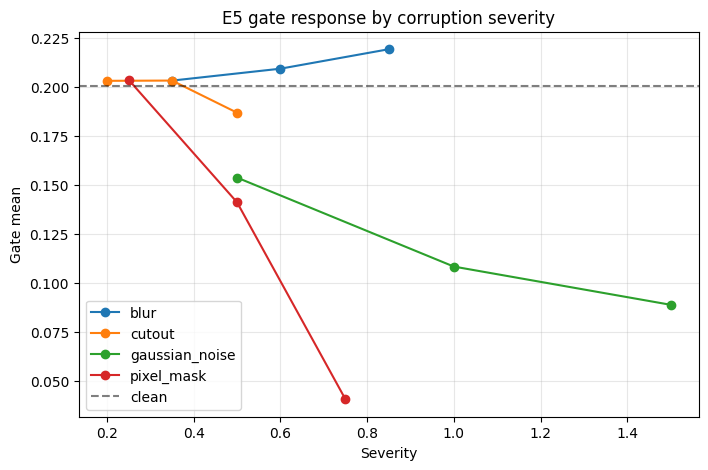

In [17]:
if pd is not None:
    signal_df = pd.read_csv(SIGNAL_CURVES_CSV)
    e5_signal = signal_df[signal_df['model'].eq(FINAL_LABEL)].copy()
    display(e5_signal[['corruption', 'severity', 'acc', 'gate_mean', 'gate_raw_mean', 'familiarity_mean', 'ood_risk_mean']])

    fig, ax = plt.subplots(figsize=(8, 5))
    for corr, sub in e5_signal[e5_signal['corruption'] != 'clean'].groupby('corruption'):
        ax.plot(sub['severity'], sub['gate_mean'], marker='o', label=corr)
    clean_gate = e5_signal[e5_signal['corruption'].eq('clean')]['gate_mean']
    if not clean_gate.empty:
        ax.axhline(clean_gate.iloc[0], linestyle='--', color='k', alpha=0.5, label='clean')
    ax.set_xlabel('Severity')
    ax.set_ylabel('Gate mean')
    ax.set_title('E5 gate response by corruption severity')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()
else:
    print('pandas no disponible; omitiendo tabla/grafico de curvas.')


## Pipeline final robustecido

Esta es ahora la ruta principal de entrenamiento y evaluación de E5. No es una sección de observaciones: el loop final entrena E5 y sus ablaciones con múltiples semillas, evalúa métricas de calibración/selección/OOD dentro de `evaluate_extended`, guarda predicciones pareadas por muestra y produce los artefactos de reporte científico.

El protocolo principal conserva `train+val` redividido por continuidad con el experimento histórico; el split oficial Flowers102 se ejecuta como evaluación secundaria para comparabilidad. Las decisiones metodológicas están comentadas junto al código donde se aplican y citan la referencia bibliográfica que las motiva.


In [18]:
def _display_records(records, title=None):
    if title:
        print(title)
    if pd is not None:
        display(pd.DataFrame(records))
    else:
        for row in records:
            print(row)


# Lee et al. proponen distancia Mahalanobis en features como baseline OOD simple;
# se ajusta sobre train y se usa dentro de la misma evaluacion E5.
@torch.no_grad()
def fit_mahalanobis_diagonal(model, loader, max_batches=None):
    model.eval()
    max_batches = cfg.eval_max_batches if max_batches is None else max_batches
    sums = defaultdict(lambda: None)
    sq_sums = defaultdict(lambda: None)
    counts = defaultdict(int)
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        feats = model.backbone(x)
        pooled = model.pool(feats).flatten(1)
        for cls in y.unique():
            mask = y == cls
            vals = pooled[mask]
            c = int(cls.item())
            s = vals.sum(dim=0)
            ss = (vals ** 2).sum(dim=0)
            sums[c] = s if sums[c] is None else sums[c] + s
            sq_sums[c] = ss if sq_sums[c] is None else sq_sums[c] + ss
            counts[c] += vals.size(0)
    classes = sorted(counts)
    means, vars_ = [], []
    for c in classes:
        mean = sums[c] / max(1, counts[c])
        var = sq_sums[c] / max(1, counts[c]) - mean ** 2
        means.append(mean)
        vars_.append(var.clamp_min(1e-4))
    return {'classes': classes, 'means': torch.stack(means), 'vars': torch.stack(vars_)}

@torch.no_grad()
def mahalanobis_scores_from_feats(feats, stats):
    pooled = F.adaptive_avg_pool2d(feats, (1, 1)).flatten(1)
    means = stats['means'].to(pooled.device)
    vars_ = stats['vars'].to(pooled.device)
    d = ((pooled[:, None, :] - means[None, :, :]) ** 2 / vars_[None, :, :]).sum(dim=2)
    return d.min(dim=1).values

def _prediction_rows_from_suite(metrics):
    rows = []
    for rec in [metrics.get('clean_record', {})]:
        rows.extend(rec.get('predictions', []))
    for records in metrics.get('corruption_records', {}).values():
        for rec in records:
            rows.extend(rec.get('predictions', []))
    return rows

def _clean_metrics_for_json(metrics):
    clean = dict(metrics)
    for rec_key in ['clean_record', 'corruption_records']:
        clean.pop(rec_key, None)
    return clean

def run_epoch_resnet_transfer(model, loader, optimizer, train, config=cfg):
    model.train(train)
    configure_resnet_transfer_baseline(model, config, train=train)
    totals = {'loss': 0.0, 'acc': 0.0, 'n': 0}
    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if (not train) and bi >= config.max_val_batches_debug:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_model = apply_train_corruption(x.clone()) if train else x
        if train:
            optimizer.zero_grad(set_to_none=True)
        logits = model(x_model)
        loss = criterion(logits, y)
        if train:
            loss.backward()
            optimizer.step()
        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['acc'] += (logits.argmax(1) == y).float().mean().item() * bs
        totals['n'] += bs
    for k in ['loss', 'acc']:
        totals[k] /= max(1, totals['n'])
    return totals


def train_resnet_transfer_for_seed(seed_value, config, train_loader, val_loader, test_loader, artifacts_dir, protocol_meta):
    seed_everything(seed_value)
    variant_name = RESNET_TRANSFER_VARIANT
    variant_dir = Path(artifacts_dir) / f'seed_{seed_value}' / variant_name
    variant_dir.mkdir(parents=True, exist_ok=True)
    print(f'===== seed={seed_value} variant={variant_name} transfer baseline =====')
    model = make_resnet_transfer_baseline(config)
    opt = make_optimizer_resnet_transfer(model, config)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=config.scheduler_factor, patience=config.scheduler_patience)
    best_acc, best_state, no_imp = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, config.epochs_baseline_max + 1):
        tr = run_epoch_resnet_transfer(model, train_loader, opt, train=True, config=config)
        va = run_epoch_resnet_transfer(model, val_loader, opt, train=False, config=config)
        sch.step(va['acc'])
        print(f'[{variant_name} seed {seed_value} {ep:02d}] tr_acc={tr["acc"]:.4f} val_acc={va["acc"]:.4f}')
        if va['acc'] > best_acc + config.early_stop_min_delta:
            best_acc = va['acc']
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= config.early_stop_patience:
                print(f'{variant_name} early stop at epoch {ep}.')
                break
    model.load_state_dict(best_state)
    mahal_stats = fit_mahalanobis_diagonal(model, train_loader) if config.run_critical_mahalanobis else None
    metrics = evaluate_attractor_suite(model, test_loader, return_predictions=True, mahalanobis_stats=mahal_stats)
    clean_record = metrics.get('clean_record', {})
    corr_records = metrics.get('corruption_records', {})
    signal_rows = _single_signal_curve_rows(variant_name, RESNET_TRANSFER_LABEL, clean_record, corr_records)
    pred_rows = _prediction_rows_from_suite(metrics)
    summary = _clean_metrics_for_json(metrics)
    summary.update({
        'seed': int(seed_value),
        'variant': variant_name,
        'model': RESNET_TRANSFER_LABEL,
        'best_val': float(best_acc),
        'protocol': protocol_meta['protocol'],
        'split_seed': protocol_meta['split_seed'],
        'resnet_transfer_train_mode': config.resnet_transfer_train_mode,
    })
    torch.save({'name': variant_name, 'label': RESNET_TRANSFER_LABEL, 'state_dict': model.state_dict(), 'config': asdict(config), 'best_val': float(best_acc)}, variant_dir / f'{variant_name}_best.pt')
    _write_json({'summary': summary, 'protocol_meta': protocol_meta, 'config': asdict(config)}, variant_dir / 'metrics.json')
    _write_records_csv(signal_rows, variant_dir / 'signal_curves.csv')
    _write_records_csv(pred_rows, variant_dir / 'predictions.csv')
    return summary, pred_rows, signal_rows


# Bouthillier et al. motivan que cada variante se entrene bajo varias semillas;
# este helper ejecuta el pipeline original P1/P2/P3, no una evaluacion paralela.
def train_variant_for_seed(variant_name, seed_value, config, train_loader, val_loader, test_loader, artifacts_dir, protocol_meta):
    seed_everything(seed_value)
    spec = experiment_specs()[variant_name]
    variant_cfg = config_for_experiment(config, variant_name)
    variant_dir = Path(artifacts_dir) / f'seed_{seed_value}' / variant_name
    variant_dir.mkdir(parents=True, exist_ok=True)

    print(f'===== seed={seed_value} variant={variant_name} phase 1 =====')
    shared_model = make_attractor_variant(variant_cfg, variant_name)
    opt_p1 = make_optimizer_phase1(shared_model, variant_cfg)
    sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(opt_p1, mode='min', factor=variant_cfg.scheduler_factor, patience=variant_cfg.scheduler_patience)
    best_p1, best_p1_state, no_imp1 = float('inf'), copy.deepcopy(shared_model.state_dict()), 0
    for ep in range(1, variant_cfg.epochs_phase1_max + 1):
        tr = run_epoch_phase1(shared_model, train_loader, opt_p1, train=True)
        va = run_epoch_phase1(shared_model, val_loader, opt_p1, train=False)
        sch_p1.step(va['loss'])
        print(f'[{variant_name} seed {seed_value} P1 {ep:02d}] tr_loss={tr["loss"]:.4f} val_loss={va["loss"]:.4f}')
        if va['loss'] < best_p1 - variant_cfg.early_stop_min_delta:
            best_p1 = va['loss']
            best_p1_state = copy.deepcopy(shared_model.state_dict())
            no_imp1 = 0
        else:
            no_imp1 += 1
            if no_imp1 >= variant_cfg.early_stop_patience:
                break

    model = make_attractor_variant(variant_cfg, variant_name)
    model.load_state_dict(best_p1_state, strict=False)
    reset_gate_calibration_from_config(model, variant_cfg)
    sanity_check_forward(model, train_loader, variant_cfg)
    model = train_phase2(model, variant_name, variant_cfg, train_loader=train_loader, val_loader=val_loader)
    phase2_gate_sanity(model, train_loader)
    anti_weight = spec.get('antipareidolia_weight', variant_cfg.antipareidolia_weight)
    model, best_val = train_phase3(model, variant_name, anti_weight, variant_cfg, train_loader=train_loader, val_loader=val_loader)

    mahal_stats = fit_mahalanobis_diagonal(model, train_loader) if variant_cfg.run_critical_mahalanobis else None
    metrics = evaluate_attractor_suite(model, test_loader, return_predictions=True, mahalanobis_stats=mahal_stats)
    clean_record = metrics.get('clean_record', {})
    corr_records = metrics.get('corruption_records', {})
    signal_rows = _single_signal_curve_rows(variant_name, spec['label'], clean_record, corr_records)
    pred_rows = _prediction_rows_from_suite(metrics)
    summary = _clean_metrics_for_json(metrics)
    summary.update({
        'seed': int(seed_value),
        'variant': variant_name,
        'model': spec['label'],
        'best_val': float(best_val),
        'protocol': protocol_meta['protocol'],
        'split_seed': protocol_meta['split_seed'],
    })

    torch.save({'name': variant_name, 'label': spec['label'], 'state_dict': model.state_dict(), 'config': asdict(variant_cfg), 'best_val': float(best_val)}, variant_dir / f'{variant_name}_best.pt')
    _write_json({'summary': summary, 'protocol_meta': protocol_meta, 'config': asdict(variant_cfg)}, variant_dir / 'metrics.json')
    _write_records_csv(signal_rows, variant_dir / 'signal_curves.csv')
    _write_records_csv(pred_rows, variant_dir / 'predictions.csv')
    return summary, pred_rows, signal_rows

def _aggregate_mean_std(rows, group_key='variant'):
    numeric_keys = sorted(k for row in rows for k, v in row.items() if isinstance(v, (int, float, bool, np.floating)) and k not in ['seed'])
    out = []
    for key in sorted(set(row[group_key] for row in rows)):
        sub = [row for row in rows if row[group_key] == key]
        rec = {group_key: key, 'n': len(sub)}
        label = next((row.get('model') for row in sub if row.get('model')), key)
        rec['model'] = label
        for nk in numeric_keys:
            vals = [float(row[nk]) for row in sub if nk in row and row[nk] is not None and not (isinstance(row[nk], float) and math.isnan(row[nk]))]
            if vals:
                rec[f'{nk}_mean'] = float(np.mean(vals))
                rec[f'{nk}_std'] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        out.append(rec)
    return out

# Bootstrap 95%: transforma los aciertos por muestra en intervalos de confianza
# para no reportar solo estimadores puntuales.
def _bootstrap_acc_ci(pred_rows, iters=1000, seed_value=123):
    y = np.asarray([bool(r['correct']) for r in pred_rows], dtype=float)
    if y.size == 0:
        return {'acc_boot_low': float('nan'), 'acc_boot_high': float('nan')}
    rng = np.random.default_rng(seed_value)
    vals = [y[rng.integers(0, y.size, y.size)].mean() for _ in range(iters)]
    return {'acc_boot_low': float(np.quantile(vals, 0.025)), 'acc_boot_high': float(np.quantile(vals, 0.975))}

def _binom_two_sided_p(k, n):
    if n <= 0:
        return 1.0
    k = int(min(k, n - k))
    if k < 0:
        return float('nan')
    log_pk = math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1) - n * math.log(2.0)
    pk = math.exp(log_pk) if log_pk > math.log(float.fromhex('0x1p-1022')) else 0.0
    tail_scale = 1.0
    ratio_prod = 1.0
    for i in range(k, 0, -1):
        ratio_prod *= i / (n - i + 1)
        tail_scale += ratio_prod
        if ratio_prod == 0.0:
            break
    return float(min(1.0, 2.0 * pk * tail_scale))

# McNemar usa las predicciones pareadas E5-vs-ablation sobre los mismos ejemplos,
# que es el contraste adecuado para clasificadores en un test compartido.
def _mcnemar_rows(predictions_by_key, reference_variant=FINAL_VARIANT):
    rows = []
    for seed_value in sorted({k[0] for k in predictions_by_key}):
        ref = predictions_by_key.get((seed_value, reference_variant), [])
        ref_by_id = {(r['corruption'], float(r['severity']), int(r['sample_id'])): bool(r['correct']) for r in ref}
        for (s, variant), rows_variant in predictions_by_key.items():
            if s != seed_value or variant == reference_variant:
                continue
            b = c = 0
            for r in rows_variant:
                key = (r['corruption'], float(r['severity']), int(r['sample_id']))
                if key not in ref_by_id:
                    continue
                ref_ok = ref_by_id[key]
                var_ok = bool(r['correct'])
                b += int(ref_ok and not var_ok)
                c += int((not ref_ok) and var_ok)
            rows.append({'seed': seed_value, 'reference': reference_variant, 'variant': variant, 'b_ref_only': b, 'c_variant_only': c, 'mcnemar_p': _binom_two_sided_p(min(b, c), b + c)})
    return rows

def _ood_score_rows(predictions_by_key):
    rows = []
    score_names = ['ood_risk', 'dq_norm', 'gate_entropy', 'mahalanobis']
    for (seed_value, variant), pred_rows in predictions_by_key.items():
        y = [0 if r['corruption'] == 'clean' else 1 for r in pred_rows]
        for score in score_names:
            vals = [r.get(score) for r in pred_rows]
            valid = [(yy, vv) for yy, vv in zip(y, vals) if vv is not None]
            if not valid:
                continue
            yy, vv = zip(*valid)
            metrics = _binary_auc_ap(yy, vv)
            rows.append({'seed': seed_value, 'variant': variant, 'score': score, **metrics})
        inv_fam = [1.0 - float(r['familiarity']) for r in pred_rows if 'familiarity' in r]
        if inv_fam:
            metrics = _binary_auc_ap(y[:len(inv_fam)], inv_fam)
            rows.append({'seed': seed_value, 'variant': variant, 'score': '1_minus_familiarity', **metrics})
    return rows

# Mitchell et al. y Gebru et al. exigen reportar uso previsto, limites,
# datos, entorno y condiciones de evaluacion; se exporta junto a los resultados.
def build_model_card_and_datasheet(config, protocol_meta, summary_rows):
    env = {
        'python': platform.python_version(),
        'platform': platform.platform(),
        'torch': torch.__version__,
        'torchvision': torchvision.__version__,
        'cuda_available': torch.cuda.is_available(),
        'cuda_device': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    model_card = {
        'model': FINAL_LABEL,
        'intended_use': 'Proof of concept para Flowers102 bajo corrupciones sinteticas controladas.',
        'out_of_scope': 'Identificacion botanica abierta, despliegue en campo o decisiones de alto impacto sin validacion externa.',
        'known_failure_modes': 'Ruido gaussiano y pixel masking severos; shifts naturales no validados.',
        'primary_protocol': config.benchmark_protocol,
        'critical_variants': list(critical_variant_names(config)),
    }
    datasheet = {
        'dataset': 'Oxford Flowers102',
        'primary_protocol': protocol_meta,
        'secondary_protocol': 'official' if config.run_official_split_secondary_eval else None,
        'corruptions': strict_suite,
        'seeds': list(config.critical_seeds),
        'environment': env,
        'artifacts_dir': config.critical_artifacts_dir,
        'summary_rows': len(summary_rows),
    }
    return model_card, datasheet

def run_official_split_secondary_eval(reference_checkpoint, config, artifacts_dir):
    if not config.run_official_split_secondary_eval:
        return []
    print('===== secondary official split eval =====')
    off_train, off_val, off_test, off_meta = build_datasets(config, protocol='official')
    # Secondary comparability retrains only the reference E5 over official train/val.
    return_rows = []
    seed_value = int(config.critical_seeds[0])
    summary, _, _ = train_variant_for_seed(FINAL_VARIANT, seed_value, config, off_train, off_val, off_test, Path(artifacts_dir) / 'official_secondary', off_meta)
    summary['secondary_eval'] = True
    return_rows.append(summary)
    return return_rows

# Punto de entrada del pipeline final: multi-seed, ablaciones, metricas estandar,
# split oficial secundario y artefactos reproducibles en una sola ruta.
def run_critical_protocol(config=cfg):
    artifacts_dir = Path(config.critical_artifacts_dir)
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    all_summary = []
    all_signal_rows = []
    predictions_by_key = {}

    if not config.critical_protocol_enabled:
        print('critical_protocol_enabled=False; protocolo critico no ejecutado.')
        return [], [], [], [], []

    for seed_value in config.critical_seeds:
        seed_everything(seed_value)
        train_loader, val_loader, test_loader, protocol_meta = build_datasets(config, protocol=config.benchmark_protocol, seed_override=seed_value)
        for variant_name in critical_variant_names(config):
            if variant_name == RESNET_TRANSFER_VARIANT:
                summary, pred_rows, signal_rows = train_resnet_transfer_for_seed(seed_value, config, train_loader, val_loader, test_loader, artifacts_dir, protocol_meta)
            else:
                summary, pred_rows, signal_rows = train_variant_for_seed(variant_name, seed_value, config, train_loader, val_loader, test_loader, artifacts_dir, protocol_meta)
            all_summary.append(summary)
            all_signal_rows.extend(signal_rows)
            predictions_by_key[(seed_value, variant_name)] = pred_rows

    critical_summary_rows = _aggregate_mean_std(all_summary)
    bootstrap_rows = []
    if config.run_critical_bootstrap:
        for (seed_value, variant), pred_rows in predictions_by_key.items():
            bootstrap_rows.append({'seed': seed_value, 'variant': variant, **_bootstrap_acc_ci(pred_rows, config.bootstrap_iters, seed_value)})
    stat_tests_rows = _mcnemar_rows(predictions_by_key) if config.run_critical_mcnemar else []
    ood_scores_rows = _ood_score_rows(predictions_by_key) if config.run_critical_ood_scores else []
    official_rows = run_official_split_secondary_eval(None, config, artifacts_dir)
    model_card, datasheet = build_model_card_and_datasheet(config, DATASET_PROTOCOL_META, all_summary)

    _write_records_csv(all_summary, artifacts_dir / 'critical_seed_metrics.csv')
    _write_records_csv(critical_summary_rows, artifacts_dir / 'critical_summary.csv')
    _write_records_csv(all_signal_rows, artifacts_dir / 'critical_signal_curves.csv')
    _write_records_csv(stat_tests_rows, artifacts_dir / 'critical_mcnemar.csv')
    _write_records_csv(bootstrap_rows, artifacts_dir / 'critical_bootstrap_ci.csv')
    _write_records_csv(ood_scores_rows, artifacts_dir / 'critical_ood_scores.csv')
    _write_records_csv(official_rows, artifacts_dir / 'official_split_secondary.csv')
    _write_json(model_card, artifacts_dir / 'model_card_e5.json')
    _write_json(datasheet, artifacts_dir / 'datasheet_setting.json')

    globals()['critical_summary_df'] = pd.DataFrame(critical_summary_rows) if pd is not None else critical_summary_rows
    globals()['stat_tests_df'] = pd.DataFrame(stat_tests_rows) if pd is not None else stat_tests_rows
    globals()['calibration_df'] = pd.DataFrame(all_summary)[['seed', 'variant', 'ece_clean', 'ece_corrupt_avg', 'nll_clean', 'nll_corrupt_avg', 'brier_clean', 'brier_corrupt_avg']] if pd is not None else all_summary
    globals()['ood_scores_df'] = pd.DataFrame(ood_scores_rows) if pd is not None else ood_scores_rows
    globals()['official_split_secondary_df'] = pd.DataFrame(official_rows) if pd is not None else official_rows

    print('saved critical artifacts:', artifacts_dir)
    _display_records(critical_summary_rows, 'critical_summary_df')
    _display_records(stat_tests_rows[:20], 'stat_tests_df sample')
    _display_records(ood_scores_rows[:20], 'ood_scores_df sample')
    return critical_summary_rows, stat_tests_rows, bootstrap_rows, ood_scores_rows, official_rows

critical_summary_rows, stat_tests_rows, bootstrap_rows, ood_scores_rows, official_split_secondary_rows = run_critical_protocol(cfg)


===== seed=42 variant=e5_combined_dropout_ood_tau_150 phase 1 =====
[e5_combined_dropout_ood_tau_150 seed 42 P1 01] tr_loss=1.2240 val_loss=1.3068
[e5_combined_dropout_ood_tau_150 seed 42 P1 02] tr_loss=1.2131 val_loss=1.3522
[e5_combined_dropout_ood_tau_150 seed 42 P1 03] tr_loss=1.2192 val_loss=1.4340
[e5_combined_dropout_ood_tau_150 seed 42 P1 04] tr_loss=1.2341 val_loss=1.4846
logits: (4, 102) | gate: (4, 1, 1, 1) | prior: (4, 1, 1, 1) | raw: (4, 1, 1, 1) | sigreg: 17.544357299804688 | denoise: 0.03180927410721779 | vq: 0.8984712362289429
[e5_combined_dropout_ood_tau_150 P2 01] tr_loss=22.3781 val_loss=15.3219 val_gate=0.0704 val_prior=0.4515 val_raw=0.1127 val_sigreg=12.3690
[e5_combined_dropout_ood_tau_150 P2 02] tr_loss=13.2306 val_loss=11.3740 val_gate=0.0755 val_prior=0.4647 val_raw=0.1205 val_sigreg=11.1767
[e5_combined_dropout_ood_tau_150 P2 03] tr_loss=10.0025 val_loss=9.1784 val_gate=0.0816 val_prior=0.4753 val_raw=0.1304 val_sigreg=11.3945
[e5_combined_dropout_ood_tau_150

,variant,n,model,aurc_confidence_clean_mean,aurc_confidence_clean_std,aurc_confidence_corrupt_avg_mean,aurc_confidence_corrupt_avg_std,aurc_gate_clean_mean,aurc_gate_clean_std,aurc_gate_corrupt_avg_mean,...,pareidolia_rate_mean,pareidolia_rate_std,pareto_strict_success_mean,pareto_strict_success_std,pred_change_rate_mean,pred_change_rate_std,split_seed_mean,split_seed_std,strict_acceptance_success_mean,strict_acceptance_success_std
0,attractor_disabled,5,Ablation attractor disabled,0.049209,0.003351,0.299944,0.011596,0.164576,0.019378,0.414155,...,0.000000,0.000000,0.2,0.447214,0.995070,0.001906,44.0,1.581139,0.2,0.447214
1,e5_combined_dropout_ood_tau_150,5,E5 combined dropout + OOD tau 1.50,0.048429,0.004009,0.298905,0.009852,0.166928,0.009213,0.417896,...,0.000114,0.000157,1.0,0.000000,0.990161,0.002232,44.0,1.581139,1.0,0.000000
2,freeze_vq_phase3,5,Ablation freeze VQ Phase 3,0.309811,0.026399,0.649879,0.026591,0.494904,0.018821,0.740099,...,0.000000,0.000000,0.0,0.000000,0.990020,0.001515,44.0,1.581139,0.0,0.000000
3,no_antipareidolia,5,Ablation no anti-pareidolia,0.048090,0.004323,0.295818,0.012649,0.166714,0.015240,0.412172,...,0.000211,0.000218,1.0,0.000000,0.989990,0.000760,44.0,1.581139,1.0,0.000000
4,no_familiarity,5,Ablation no familiarity,0.051333,0.004147,0.299176,0.008777,0.208815,0.006513,0.453771,...,0.000000,0.000000,1.0,0.000000,0.989527,0.005406,44.0,1.581139,1.0,0.000000
5,no_ood,5,Ablation no OOD,0.049529,0.003721,0.292912,0.020870,0.162134,0.012296,0.410015,...,0.000000,0.000000,1.0,0.000000,0.989768,0.000557,44.0,1.581139,1.0,0.000000
6,partial_unfreeze_backbone,5,Ablation partial backbone unfreeze,0.023738,0.001629,0.330136,0.015839,0.147625,0.009196,0.408285,...,0.000033,0.000039,1.0,0.000000,0.991047,0.001678,44.0,1.581139,0.8,0.447214
7,resnet18_transfer_baseline,5,ResNet18 transfer baseline,0.037597,0.008009,0.288580,0.037307,0.161847,0.015795,0.464596,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,44.0,1.581139,0.0,0.000000


stat_tests_df sample


,seed,reference,variant,b_ref_only,c_variant_only,mcnemar_p
0,42,e5_combined_dropout_ood_tau_150,no_ood,3698,4439,2.228641e-16
1,42,e5_combined_dropout_ood_tau_150,no_familiarity,4025,3409,9.548685e-13
2,42,e5_combined_dropout_ood_tau_150,no_antipareidolia,3443,4291,5.377550e-22
3,42,e5_combined_dropout_ood_tau_150,freeze_vq_phase3,25014,2341,0.000000e+00
4,42,e5_combined_dropout_ood_tau_150,partial_unfreeze_backbone,6257,6318,5.926146e-01
5,42,e5_combined_dropout_ood_tau_150,attractor_disabled,4457,3820,2.670129e-12
6,42,e5_combined_dropout_ood_tau_150,resnet18_transfer_baseline,6927,8975,2.051671e-59
7,43,e5_combined_dropout_ood_tau_150,no_ood,4095,4341,7.639050e-03
8,43,e5_combined_dropout_ood_tau_150,no_familiarity,4168,4039,1.576749e-01
9,43,e5_combined_dropout_ood_tau_150,no_antipareidolia,4282,4071,2.157186e-02


ood_scores_df sample


,seed,variant,score,auroc,aupr
0,42,e5_combined_dropout_ood_tau_150,ood_risk,0.373047,0.896624
1,42,e5_combined_dropout_ood_tau_150,dq_norm,0.373044,0.896397
2,42,e5_combined_dropout_ood_tau_150,gate_entropy,0.426996,0.907996
3,42,e5_combined_dropout_ood_tau_150,mahalanobis,0.836667,0.983890
4,42,e5_combined_dropout_ood_tau_150,1_minus_familiarity,0.575747,0.935494
5,42,no_ood,ood_risk,0.382018,0.898227
6,42,no_ood,dq_norm,0.382016,0.898043
7,42,no_ood,gate_entropy,0.425775,0.907626
8,42,no_ood,mahalanobis,0.836797,0.983954
9,42,no_ood,1_minus_familiarity,0.574237,0.935648



## Reentrenamiento legacy de una sola corrida

Esta ruta se conserva solo para reproducir el E5 histórico de una semilla. El pipeline final de investigación es `run_critical_protocol(cfg)`, que ya ejecuta multi-seed, ablaciones, métricas estándar, pruebas pareadas y documentación de artefactos.


In [19]:
RUN_TRAINING = False

if RUN_TRAINING:
    run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    artifacts_dir = os.path.join(e5_cfg.artifacts_root, f'{e5_cfg.experiment_name}_{run_stamp}')
    os.makedirs(artifacts_dir, exist_ok=True)

    print('===== Phase 1 shared latent pretraining =====')
    shared_model = make_attractor_variant(cfg, FINAL_VARIANT)
    opt_p1 = make_optimizer_phase1(shared_model, cfg)
    sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(opt_p1, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    best_p1, best_p1_state, no_imp1 = float('inf'), copy.deepcopy(shared_model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase1_max + 1):
        tr = run_epoch_phase1(shared_model, trainloader, opt_p1, train=True)
        va = run_epoch_phase1(shared_model, valloader, opt_p1, train=False)
        sch_p1.step(va['loss'])
        print(f'[P1 {ep:02d}] tr_loss={tr["loss"]:.4f} val_loss={va["loss"]:.4f} val_sigreg={va["sigreg"]:.4f}')
        if va['loss'] < best_p1 - cfg.early_stop_min_delta:
            best_p1 = va['loss']
            best_p1_state = copy.deepcopy(shared_model.state_dict())
            no_imp1 = 0
        else:
            no_imp1 += 1
            if no_imp1 >= cfg.early_stop_patience:
                print(f'P1 early stop at epoch {ep}.')
                break
    torch.save({'state_dict': best_p1_state, 'config': asdict(cfg)}, os.path.join(artifacts_dir, 'phase1_shared_attractor.pt'))

    print(f'===== Train {FINAL_VARIANT} =====')
    model = make_attractor_variant(e5_cfg, FINAL_VARIANT)
    model.load_state_dict(best_p1_state, strict=False)
    reset_gate_calibration_from_config(model, e5_cfg)
    sanity_check_forward(model, trainloader, e5_cfg)
    model = train_phase2(model, FINAL_VARIANT, e5_cfg)
    phase2_gate_sanity(model, trainloader)
    anti_weight = experiment_specs()[FINAL_VARIANT].get('antipareidolia_weight', e5_cfg.antipareidolia_weight)
    model, best_val = train_phase3(model, FINAL_VARIANT, anti_weight, e5_cfg)
    torch.save({'name': FINAL_VARIANT, 'label': FINAL_LABEL, 'state_dict': model.state_dict(), 'config': asdict(e5_cfg), 'best_val': float(best_val)}, os.path.join(artifacts_dir, f'{FINAL_VARIANT}_best.pt'))
    print('saved:', artifacts_dir)
else:
    print('RUN_TRAINING=False; ruta legacy desactivada. El pipeline final se ejecuta con run_critical_protocol(cfg).')


RUN_TRAINING=False; ruta legacy desactivada. El pipeline final se ejecuta con run_critical_protocol(cfg).
